# Generate the HMM description, AMG, APG, AReG, viral hallmark gene, and MGE/mobility gene tables

**Will need:**

**1.** [Table of V- and VL-scores](https://raw.githubusercontent.com/AnantharamanLab/V-Score-Search/refs/heads/main/Database/VScoreData.csv) from [Zhou et al. (2024)](https://doi.org/10.1101/2024.10.24.619987)
* Last accessed: 16 October 2025
* Version: V-Score Search commit `9f8adbb` (16 April 2025)

**2.** [KEGG BRITE table 09100 (KO)](https://www.kegg.jp/kegg-bin/download_htext?htext=ko00001&format=htext&filedir=) containing KOs categorized by their BRITE hierarchy / functional categories
* Last accessed: 16 December 2025
* Version last modified 16 December 2025

**3.** [PHROG annotation table](https://phrogs.lmge.uca.fr/downloads_from_website/phrog_annot_v4.tsv)
* Last accessed: 16 December 2025
* Version: PHROG release v4 (15 June 2022)

**2.** [List of CAZy activities](https://bcb.unl.edu/dbCAN2/download/Databases/V12/CAZyDB.08062022.fam-activities.txt) from CAZyDB ([Drula et al., 2022 *Nucleic Acids Res*](https://doi.org/10.1093/nar/gkab1045))
* Last accessed: 16 October 2025
* Version: dbCAN HMMdb v12 (`CAZyDB.08062022.fam-activities.txt`) (02 August 2023)

**3.** `hmm_table_template.txt` from METABOLIC ([Zhou et al., 2022 *Microbiome*](https://doi.org/10.1186/s40168-021-01213-8)) - maps METABOLIC’s custom HMMs to functions ([link](https://github.com/AnantharamanLab/METABOLIC/raw/refs/heads/master/METABOLIC_template_and_database.tgz))
* Last accessed: 16 October 2025
* Version: METABOLIC commit "e2f1de6" (12 June 2023)

**4.** ["FOAM-hmm_rel1a.hmm.gz`](https://osf.io/5ba2v/files/bdpv5) from the Functional Ontology Assignments for Metagenomes (FOAM) database ([Prestat et al., 2014 *Nucleic Acids Res*](https://doi.org/10.1093/nar/gku702))
* Last accessed: 16 October 2025
* Version modified: 10 January 2023

**5.** [`FOAM-onto_rel1.tsv`](https://osf.io/5ba2v/files/muan4) - FOAM annotations/functions table
* Last accessed: 16 October 2025
* Version last modified 10 January 2023

**6.** [`CAMPER_hmm_scores.tsv`](https://raw.githubusercontent.com/WrightonLabCSU/CAMPER/refs/heads/main/CAMPER_hmm_scores.tsv) from the [Curated Annotations for Microbial (Poly)phenol Enzymes and Reactions (CAMPER)](https://github.com/WrightonLabCSU/CAMPER/tree/main) database ([McGivern et al., 2024](https://doi.org/10.1101/2023.09.24.559193))
* Last accessed: 15 December 2025
* Version last modified 20 September 2023

**9.** [`amg_database.tsv`](https://raw.githubusercontent.com/WrightonLabCSU/DRAM/refs/heads/master/data/amg_database.tsv) from the DRAM-V AMG database ([Shaffer et al., 2020 *Nucleic Acids Res*](https://doi.org/10.1093/nar/gkaa621))
* Last accessed: 11 December 2025
* Version last modified 3 March 2020

**10.** `plasmid_hallmark_annotation.txt` from the [geNomad database](https://zenodo.org/records/14886553) ([Camargo et al., 2024 *Nat Biotechnol*](https://doi.org/10.1038/s41587-023-01953-y))
* Last accessed: 16 October 2025
* Version: 1.9 (18 February 2025)

For demonstration, these were pre-downloaded and are located in the `data` folder **except** for the FOAM `.hmm` file. Since this is a part of the CheckAMG database, it can be found in the database folder created when running `CheckAMG download`.

In [269]:
! pip install pandas matplotlib --quiet

In [270]:
import pandas as pd
pd.set_option('display.max_colwidth', 100)
from difflib import SequenceMatcher
from collections import defaultdict
import os
import re

## 1. Reformat the V-Score table

In [271]:
vscores = pd.read_csv("./data/VScoreData.csv")
vscores = vscores.rename(
    columns={
        "Accession": "id",
        "Protein Function": "name",
        "V-Score": "V-score",
        "Log10[Hit Number]": "VL-score",
        "Database Origin": "db"
    }
)
vscores = vscores[vscores.db.isin(["KEGG", "Pfam", "PHROG"])] # Remove databases that aren't used by CheckAMG

# Remove duplicates if any
metabolivscoresc_desc_df = vscores.drop_duplicates(subset=['id', 'name', 'db'])
vscores

,id,name,V-score,VL-score,db
0,K04763,integrase/recombinase XerD,10.00,4.890952,KEGG
1,K14059,integrase,10.00,4.882297,KEGG
2,K03733,integrase/recombinase XerC,10.00,4.875391,KEGG
3,K00571,site-specific DNA-methyltransferase (adenine-specific) [EC:2.1.1.72],10.00,4.829278,KEGG
4,K06909,phage terminase large subunit,10.00,4.826871,KEGG
...,...,...,...,...,...
243425,phrog_22476,NaN,0.01,0.000000,PHROG
243426,phrog_4110,NaN,0.01,0.000000,PHROG
243427,phrog_17200,NaN,0.01,0.000000,PHROG
243428,phrog_6460,NaN,0.01,0.000000,PHROG


In [272]:
vscores.to_csv("../CheckAMG/files/vscores.tsv", sep="\t", index=False)

In [273]:
id_to_desc = vscores[['id', 'db', 'name']]
id_to_desc

,id,db,name
0,K04763,KEGG,integrase/recombinase XerD
1,K14059,KEGG,integrase
2,K03733,KEGG,integrase/recombinase XerC
3,K00571,KEGG,site-specific DNA-methyltransferase (adenine-specific) [EC:2.1.1.72]
4,K06909,KEGG,phage terminase large subunit
...,...,...,...
243425,phrog_22476,PHROG,NaN
243426,phrog_4110,PHROG,NaN
243427,phrog_17200,PHROG,NaN
243428,phrog_6460,PHROG,NaN


In [274]:
id_to_desc["db"].value_counts()

db
PHROG    38878
KEGG     20005
Pfam     10835
Name: count, dtype: int64

## 2. Construct the all HMM/ID to description/function table

### 2.1. Add the protein families from KEGG

In [275]:
kegg_path = './data/ko00001.keg'

a_id = a_name = None
b_id = b_name = None
c_id = c_name = c_path = None

rows = []

ra = re.compile(r"^A\s*([0-9]{5})\s+(.*)$")
rb = re.compile(r"^B\s*([0-9]{5})\s+(.*)$")
rc = re.compile(r"^C\s*([0-9]{5})\s+(.*)$")
rd = re.compile(r"^D\s*(K[0-9]{5})\s+(.*)$")
rpath = re.compile(r"\[PATH:(ko[0-9]{5})\]")

with open(kegg_path, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        s = line.strip()
        if not s or s[0] in "#!+":
            continue
        if s in {"A", "B", "C", "D"}:
            continue

        m = ra.match(s)
        if m:
            a_id, a_name = m.group(1), m.group(2).strip()
            b_id = b_name = None
            c_id = c_name = c_path = None
            continue

        m = rb.match(s)
        if m:
            b_id, b_name = m.group(1), m.group(2).strip()
            c_id = c_name = c_path = None
            continue

        m = rc.match(s)
        if m:
            c_id, c_name = m.group(1), m.group(2).strip()
            mp = rpath.search(c_name)
            c_path = mp.group(1) if mp else None
            continue

        m = rd.match(s)
        if m:
            rows.append(
                {
                    "KO": m.group(1),
                    "A_id": a_id,
                    "A_name": a_name,
                    "B_id": b_id,
                    "B_name": b_name,
                    "C_id": c_id,
                    "C_name": c_name,
                    "C_path": c_path,
                    "D_desc": m.group(2).strip(),
                }
            )

ko_brite =  pd.DataFrame(rows)
ko_brite

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
0,K00844,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,HK; hexokinase [EC:2.7.1.1]
1,K12407,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,GCK; glucokinase [EC:2.7.1.2]
2,K00845,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
3,K25026,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
4,K01810,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,"GPI, pgi; glucose-6-phosphate isomerase [EC:5.3.1.9]"
...,...,...,...,...,...,...,...,...,...
63765,K07220,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,K07220; uncharacterized protein
63766,K07276,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,K07276; uncharacterized protein
63767,K07338,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,K07338; uncharacterized protein
63768,K07586,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,ygaC; uncharacterized protein


In [276]:
kegg_desc = ko_brite[['KO', 'D_desc']].rename(columns={'KO':'id', 'D_desc':'name'})
kegg_desc["db"] = "KEGG"
kegg_desc = kegg_desc[['id', 'db', 'name']].drop_duplicates().sort_values(by='id').reset_index(drop=True)
kegg_desc

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
28003,K28729,KEGG,porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1]
28004,K28730,KEGG,XG; glycoprotein XG
28005,K28731,KEGG,sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444]
28006,K28732,KEGG,sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185]


In [277]:
len(kegg_desc["id"].unique()), len(kegg_desc)

(28008, 28008)

In [278]:
kegg_desc[kegg_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.2. Add the protein families from Pfam
Parse the `Pfam-A.hmm` file in the CheckAMG database directly to ensure exact version numbers match.

In [279]:
pfam_hmm_path = "/storage2/scratch/kosmopoulos/databases/CheckAMG_db/Pfam-A.hmm"

In [280]:
pfam_to_function = {}

import re
from collections import defaultdict
from difflib import SequenceMatcher

with open(pfam_hmm_path, "r") as f:
    acc = None
    kos = []

    for line in f:
        if line.startswith("ACC"):
            acc = line.split()[1].strip()

        elif line.startswith("DESC"):
            function = line[5:].strip()
            pfam_to_function[acc] = function

        elif line.strip() == "//" and acc:
            acc = None
            function = None

In [281]:
pfam_desc = pd.DataFrame.from_dict(pfam_to_function, orient='index', columns=['name']).reset_index().rename(columns={'index':'id'})
pfam_desc["db"] = "Pfam"
pfam_desc = pfam_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
pfam_desc

,id,db,name
0,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family)
1,PF00002.30,Pfam,7 transmembrane receptor (Secretin family)
2,PF00003.29,Pfam,7 transmembrane sweet-taste receptor of 3 GCPR
3,PF00004.36,Pfam,ATPase family associated with various cellular activities (AAA)
4,PF00005.34,Pfam,ABC transporter
...,...,...,...
25540,PF26648.1,Pfam,Probable treble clef zinc finger
25541,PF26649.1,Pfam,Apical junction molecule ajm-1 alpha/beta domain
25542,PF26650.1,Pfam,Domain of unknown function (DUF8215)
25543,PF26651.1,Pfam,Family of unknown function (DUF8216)


In [282]:
len(pfam_desc["id"].unique()), len(pfam_desc)

(25545, 25545)

In [283]:
pfam_desc[pfam_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.3. Add the protein families from PHROG

In [284]:
phrog_path = "./data/phrog_annot_v4.tsv"
phrog_annots = pd.read_csv(phrog_path, sep="\t")
phrog_annots["phrog_id"] = phrog_annots["phrog"].apply(lambda x: "phrog_" + str(x))
phrog_annots

,phrog,color,annot,category,phrog_id
0,1,#fea328,integrase,integration and excision,phrog_1
1,2,#3e83f6,terminase large subunit,head and packaging,phrog_2
2,3,#a861e3,transcriptional repressor,transcription regulation,phrog_3
3,4,#a861e3,transcriptional repressor,transcription regulation,phrog_4
4,5,#35d7ff,tail completion or Neck1 protein,connector,phrog_5
...,...,...,...,...,...
109399,109400,#c9c9c9,NaN,unknown function,phrog_109400
109400,109401,#c9c9c9,NaN,unknown function,phrog_109401
109401,109402,#c9c9c9,NaN,unknown function,phrog_109402
109402,109403,#c9c9c9,NaN,unknown function,phrog_109403


In [285]:
phrog_desc = phrog_annots[["phrog", "annot"]].copy()
phrog_desc["phrog"] = "phrog_" + phrog_desc["phrog"].astype(str)
phrog_desc = phrog_desc.rename(columns={"phrog": "id", "annot": "name"})
phrog_desc["db"] = "PHROG"
phrog_desc = phrog_desc[["id", "db", "name"]].sort_values("id").reset_index(drop=True)
phrog_desc

,id,db,name
0,phrog_1,PHROG,integrase
1,phrog_10,PHROG,major head protein
2,phrog_100,PHROG,SbcD-like subunit of palindrome specific endonuclease
3,phrog_1000,PHROG,NaN
4,phrog_10000,PHROG,NaN
...,...,...,...
109399,phrog_99995,PHROG,NaN
109400,phrog_99996,PHROG,NaN
109401,phrog_99997,PHROG,NaN
109402,phrog_99998,PHROG,NaN


In [286]:
len(phrog_desc["id"].unique()), len(phrog_desc)

(109404, 109404)

In [287]:
phrog_desc[phrog_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.4. Add the protein families from the dbCAN3 (CAZy) database

In [288]:
cazy_file_path = './data/CAZyDB.08062022.fam-activities.txt'

# Read the file, skipping lines that start with '#', and replacing '\t' within fields with a space
cazy = []
with open(cazy_file_path, 'r') as file:
    for line in file:
        if not line.startswith('#'):
            # Replace '\t' within fields with a space
            parts = line.split('\t')
            if len(parts) > 2:
                cleaned_line = parts[0] + '\t' + ' '.join(parts[1:])
            else:
                cleaned_line = line
            cazy.append(cleaned_line.strip().split('\t', 1))  # Split into two columns only on the first tab

# Convert the cleaned data into a DataFrame
cazy_desc = pd.DataFrame(cazy, columns=['id', 'name'])
# Remove leading whitespace from the 'name' column
cazy_desc['name'] = cazy_desc['name'].str.lstrip()

cazy_desc["db"] = "dbCAN"
cazy_desc = cazy_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
cazy_desc

,id,db,name
0,AA0,dbCAN,None
1,AA1,dbCAN,Laccase / p-diphenol:oxygen oxidoreductase / ferroxidase (EC 1.10.3.2); ; ferroxidase (EC 1.10.3...
2,AA10,dbCAN,AA10 (formerly CBM33) proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs);...
3,AA11,dbCAN,AA11 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of chit...
4,AA12,dbCAN,The pyrroloquinoline quinone-dependent oxidoreductase activity was demonstrated for the CC1G_095...
...,...,...,...
461,PL5,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
462,PL6,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
463,PL7,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
464,PL8,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [289]:
len(cazy_desc["id"].unique()), len(cazy_desc)

(466, 466)

In [290]:
cazy_desc[cazy_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.5. Add the protein families from the METABOLIC database

In [291]:
# Define the path to the table file
table_file_path = './data/hmm_table_template.txt'

# Read the table into a pandas DataFrame
table_df = pd.read_csv(table_file_path, sep='\t')

# Lengthen the dataframe by splitting the "Hmm file" column based on commas
lengthened_df = table_df.assign(**{
    'Hmm file': table_df['Hmm file'].str.split(',')
}).explode('Hmm file')

# Strip whitespace and ".hmm" from the "Hmm file" to form the "id"
lengthened_df['id'] = lengthened_df['Hmm file'].str.strip().str.replace('.hmm', '', regex=False)

# Conditionally select the "name" column based on whether "id" equals "Gene name"
lengthened_df['name'] = lengthened_df.apply(
    lambda row: row['Function'] if row['id'] == row['Gene name'] else row['Gene name'],
    axis=1
)

# Select relevant columns for the metabolic_desc table
metabolic_desc = lengthened_df[['id', 'name']]

# Add the constant "db" column with the value "METABOLIC"
metabolic_desc['db'] = 'METABOLIC'

# Remove duplicates if any
metabolic_desc = metabolic_desc.drop_duplicates()
metabolic_desc = metabolic_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
metabolic_desc

/tmp/ipykernel_754746/2287037470.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metabolic_desc['db'] = 'METABOLIC'


,id,db,name
0,Cyc1,METABOLIC,Iron oxidation
1,Cyc2_repCluster1,METABOLIC,Iron oxidation
2,Cyc2_repCluster2,METABOLIC,Iron oxidation
3,Cyc2_repCluster3,METABOLIC,Iron oxidation
4,CymA,METABOLIC,Iron reduction
...,...,...,...
323,soxZ,METABOLIC,sulfur-oxidizing protein SoxZ
324,sulfide_quinone_oxidoreductase_sqr,METABOLIC,sulfide:quinone oxidoreductase
325,sulfocyanin,METABOLIC,Iron oxidation
326,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase


In [292]:
len(metabolic_desc["id"].unique()), len(metabolic_desc)

(326, 328)

In [293]:
metabolic_desc[metabolic_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name
26,K00001,METABOLIC,acetaldehyde => ethanol
27,K00001,METABOLIC,alcohol dehydrogenase
57,K00812,METABOLIC,aspartate aminotransferase
58,K00812,METABOLIC,aspartate/tyrosine/aromatic aminotransferase


Resolve the duplicates by keeping the first names for each duplicated KO

In [294]:
metabolic_desc = (
    metabolic_desc
    .sort_values(["id"])  # optional: makes "first" deterministic by id
    .drop_duplicates(subset=["id"], keep="first")
    .reset_index(drop=True)
)
metabolic_desc

,id,db,name
0,Cyc1,METABOLIC,Iron oxidation
1,Cyc2_repCluster1,METABOLIC,Iron oxidation
2,Cyc2_repCluster2,METABOLIC,Iron oxidation
3,Cyc2_repCluster3,METABOLIC,Iron oxidation
4,CymA,METABOLIC,Iron reduction
...,...,...,...
321,soxZ,METABOLIC,sulfur-oxidizing protein SoxZ
322,sulfide_quinone_oxidoreductase_sqr,METABOLIC,sulfide:quinone oxidoreductase
323,sulfocyanin,METABOLIC,Iron oxidation
324,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase


### 2.6. Add families from the FOAM database

#### 2.6.1. Map FOAM HMMs to their respective KOs

In [295]:
foam_annots = pd.read_csv('./data/FOAM-onto_rel1.tsv', sep='\t')
foam_annots = foam_annots[foam_annots["L1"].notnull()] # The table has one weird row with empty data at the very end
foam_annots

,L1,L2,L3,L4,KO,Function,EC
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00134,"GAPDH, gapA; glyceraldehyde 3-phosphate dehydrogenase",1.2.1.12
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00603,fctD; glutamate formiminotransferase / 5-formyltetrahydrofolate cyclo-ligase,2.1.2.5 6.3.3.2
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K13990,FTCD; glutamate formiminotransferase / formiminotetrahydrofolate cyclodeaminase,2.1.2.5 4.3.1.4
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00918,pfkC; ADP-dependent phosphofructokinase/glucokinase,2.7.1.146 2.7.1.147
...,...,...,...,...,...,...,...
6820,21_Cellular response to stress,Response to oxidative stress,NaN,NaN,K05361,GPX4; phospholipid-hydroperoxide glutathione peroxidase,1.11.1.12
6821,21_Cellular response to stress,Response to oxidative stress,NaN,NaN,K00428,E1.11.1.5; cytochrome c peroxidase,1.11.1.5
6822,21_Cellular response to stress,Response to oxidative stress,NaN,NaN,K11207,TDPX; glutathione peroxidase-type tryparedoxin peroxidase,1.11.1.-
6823,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K00697,otsA; trehalose 6-phosphate synthase,2.4.1.15 2.4.1.347


In [296]:
foam_hmm_path = "/storage2/scratch/kosmopoulos/databases/CheckAMG_db/FOAM.hmm"

In [297]:
import re
from collections import defaultdict

acc_to_kos = defaultdict(list)
cutoffs = {}

with open(foam_hmm_path, "r") as f:
    acc = None
    kos = []

    for line in f:
        if line.startswith("NAME") or line.startswith("DESC"):
            matches = re.findall(r"KO:(K\d+)", line)
            if matches:
                kos.extend(matches)

        elif line.startswith("ACC"):
            acc = line.split()[1].strip()
            acc_to_kos.setdefault(acc, []) # ensure present even if no KOs

        elif line.startswith("TC") and acc:
            parts = line.split()
            if len(parts) > 2:
                cutoffs[acc] = (float(parts[1]), float(parts[2].rstrip(";")))
            elif len(parts) == 2:
                cutoffs[acc] = (float(parts[1]), None)

        elif line.strip() == "//" and acc:
            acc_to_kos[acc] = sorted(set(kos)) # empty list if none found
            acc = None
            kos = []

# handle file missing trailing // (still include acc with empty list)
if acc is not None:
    acc_to_kos[acc] = sorted(set(kos))

In [298]:
acc_to_kos_df = pd.DataFrame(
    [(acc, ko) for acc, kos in acc_to_kos.items() for ko in kos],
    columns=["HMM", "KO"],
)
foam_annots_hmm_mapped = foam_annots.merge(
    acc_to_kos_df,
    left_on="KO",
    right_on="KO",
    how="inner"
)
foam_annots_hmm_mapped

,L1,L2,L3,L4,KO,Function,EC,HMM
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238
...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359


#### 2.6.2. Mark cases where an HMM was assigned >1 KO

In [299]:
foam_multi_KO = foam_annots_hmm_mapped[foam_annots_hmm_mapped.groupby("HMM")["KO"].transform("nunique") > 1].sort_values(by='HMM')
foam_multi_KO

,L1,L2,L3,L4,KO,Function,EC,HMM
82378,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,PEPtides/nickel transporter [mD:m00239],K02032,ddpF; peptide/nickel transport system ATP-binding protein,NaN,HMMsoil10
81616,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,PEPtides/nickel transporter [mD:m00239],K02031,ddpD; peptide/nickel transport system ATP-binding protein,NaN,HMMsoil10
83099,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,Microcin c transporter [mD:m00349],K13896,yejF; microcin C transport system ATP-binding protein,NaN,HMMsoil10
181142,21_Cellular response to stress,Response to osmotic stress,NaN,NaN,K02484,"K02484; two-component system, OmpR family, sensor kinase",2.7.13.3,HMMsoil100048
141614,21_Cellular response to stress,Cellular response to osmotic stress,NaN,NaN,K02484,"K02484; two-component system, OmpR family, sensor kinase",2.7.13.3,HMMsoil100048
...,...,...,...,...,...,...,...,...
82195,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,PEPtides/nickel transporter [mD:m00239],K02031,ddpD; peptide/nickel transport system ATP-binding protein,NaN,HMMsoil99937
74715,12_Transporters,"ABC transporters, prokaryotic type",Oligosaccharide and polyol transporters,Multiple sugar transporter [mD:m00207],K02026,ABC.MS.P1; multiple sugar transport system permease protein,NaN,HMMsoil99951
73421,12_Transporters,"ABC transporters, prokaryotic type",Oligosaccharide and polyol transporters,Lactose/l-arabinose transporter [mD:m00199],K10190,"lacG, araQ; lactose/L-arabinose transport system permease protein",NaN,HMMsoil99951
62491,09_Carbohydrate Active enzyme - CAZy,Carbohydrate esterase,NaN,NaN,K01044,CES1; carboxylesterase 1,3.1.1.1,HMMsoil99977


In [300]:
foam_annots_hmm_mapped["HMM_N_KOs"] = foam_annots_hmm_mapped.groupby("HMM")["KO"].transform("nunique")
foam_annots_hmm_mapped

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264,1
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012,1
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333,1
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500,1
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238,1
...,...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919,1
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327,1
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016,1
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359,1


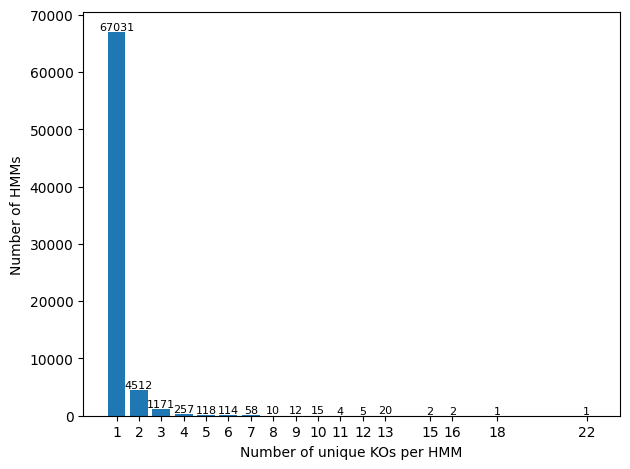

In [301]:
import matplotlib.pyplot as plt

n_ko_per_foam = foam_annots_hmm_mapped[["HMM", "HMM_N_KOs"]].drop_duplicates()
counts = (
    n_ko_per_foam["HMM_N_KOs"]
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure()
bars = plt.bar(counts.index, counts.values)

plt.xlabel("Number of unique KOs per HMM")
plt.ylabel("Number of HMMs")
plt.xticks(counts.index)

for x, y in zip(counts.index, counts.values):
    plt.text(x, y, str(y), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

#### 2.6.2. Assign functions/names to FOAM HMMs
Since it's relatively rare that a FOAM HMM was assigned >1 KO, we will have HMM descriptions be a concatenation of all unique functions.

In [302]:
foam_hmm_named = foam_annots_hmm_mapped.copy()

def _clean(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    s = str(x).strip()
    return "" if s.lower() in {"nan", "none", "null"} else s

def _pick_name_row(r):
    fn = _clean(r.get("Function", ""))
    if fn:
        return fn
    for col in ["L4", "L3", "L2", "L1"]:
        v = _clean(r.get(col, ""))
        if v:
            return v
    return ""

def _fmt_fn_ec(fn, ec):
    fn = _clean(fn)
    ec = _clean(ec)
    if not ec:
        return fn

    ecs = [e for e in ec.split() if e]
    if not ecs:
        return fn

    def _ensure_prefix(e):
        e = e.strip()
        if not e:
            return ""
        return e if e.lower().startswith("ec:") else f"[EC:{e}]"

    ecs_fmt = " ".join(_ensure_prefix(e) for e in ecs if _ensure_prefix(e))
    if fn:
        return f"{fn} {ecs_fmt}"
    return ecs_fmt

base_name = foam_hmm_named.apply(_pick_name_row, axis=1)
foam_hmm_named["_fn_ec"] = [_fmt_fn_ec(n, e) for n, e in zip(base_name, foam_hmm_named["EC"])]

foam_hmm_named["HMM_name"] = (
    foam_hmm_named.groupby("HMM")["_fn_ec"]
      .transform(lambda s: "; ".join(pd.Series(s).astype(str).str.strip().replace("", pd.NA).dropna().drop_duplicates()))
)

foam_hmm_named.drop(columns=["_fn_ec"], inplace=True)
foam_hmm_named

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
...,...,...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]


In [303]:
foam_hmm_named.to_csv('../CheckAMG/files/FOAM.tsv', sep='\t', index=False)

In [304]:
foam_desc = foam_hmm_named[["HMM", "HMM_name"]].drop_duplicates().rename(columns={"HMM": "id", "HMM_name": "name"})
foam_desc["db"] = "FOAM"
foam_desc = foam_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
foam_desc

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
73328,HMMsoil9999,FOAM,ABC.CD.A; putative ABC transport system ATP-binding protein
73329,HMMsoil99990,FOAM,"HIBADH, mmsB; 3-hydroxyisobutyrate dehydrogenase [EC:1.1.1.31]"
73330,HMMsoil99996,FOAM,ABC.MN.A; manganese/iron transport system ATP-binding protein
73331,HMMsoil99997,FOAM,ABC.SN.P; NitT/TauT family transport system permease protein


In [305]:
len(foam_desc["id"].unique()), len(foam_desc)

(73333, 73333)

In [306]:
foam_desc[foam_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.7. Add protein families from the CAMPER database

In [307]:
camper_table = './data/CAMPER_hmm_scores.tsv'
camper_desc = pd.read_csv(camper_table, sep='\t')
camper_desc = camper_desc.rename(columns={"hmm_name": "id", "definition": "name"})
camper_desc['db'] = 'CAMPER'
camper_desc = camper_desc[['id', 'db', 'name']]

# Replace few instances of hmm_name with .hmm suffix in their names
camper_desc['id'] = camper_desc['id'].str.replace('.hmm', '', regex=False)

# Remove duplicates if any
camper_desc = camper_desc.drop_duplicates()
camper_desc = camper_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
camper_desc

,id,db,name
0,AA1,CAMPER,AA1
1,AA2,CAMPER,AA2
2,AA3_2,CAMPER,AA3_2
3,AA4,CAMPER,AA4
4,AA6,CAMPER,AA6
...,...,...,...
284,K26181,CAMPER,naringenin degradation protein FdeC
285,K26182,CAMPER,naringenin degradation protein FdeH
286,K26183,CAMPER,naringenin degradation protein FdeJ
287,K26184,CAMPER,naringenin degradation protein FdeB


In [308]:
len(camper_desc["id"].unique()), len(camper_desc)

(289, 289)

In [309]:
camper_desc[camper_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.8. Combine all tables and write the final `hmm_id_to_name.tsv` table

In [310]:
all_hmms = pd.concat(
    [kegg_desc, pfam_desc, phrog_desc, cazy_desc, metabolic_desc, foam_desc, camper_desc],
    ignore_index=True
)
all_hmms

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
237366,K26181,CAMPER,naringenin degradation protein FdeC
237367,K26182,CAMPER,naringenin degradation protein FdeH
237368,K26183,CAMPER,naringenin degradation protein FdeJ
237369,K26184,CAMPER,naringenin degradation protein FdeB


In [311]:
all_hmms["db"].value_counts()

db
PHROG        109404
FOAM          73333
KEGG          28008
Pfam          25545
dbCAN           466
METABOLIC       326
CAMPER          289
Name: count, dtype: int64

In [312]:
all_hmms.to_csv('../CheckAMG/files/hmm_id_to_name.tsv', sep="\t", index=False)

## 2. Construct the AMG table

### 2.1. Metabolic proteins from KEGG

In [313]:
ko_brite["A_name"].value_counts()

A_name
Brite Hierarchies                       22367
Human Diseases                          10447
Metabolism                               8941
Environmental Information Processing     6129
Organismal Systems                       6105
Not Included in Pathway or Brite         3781
Cellular Processes                       3508
Genetic Information Processing           2492
Name: count, dtype: int64

In [314]:
ko_brite["B_name"].value_counts()

B_name
Protein families: genetic information processing      8818
Protein families: signaling and cellular processes    8089
Protein families: metabolism                          4076
Signal transduction                                   3864
Infectious disease: viral                             1979
                                                      ... 
Aging                                                  182
Sensory system                                         170
Chromosome                                             149
Excretory system                                       123
Not included in regular maps                             2
Name: count, Length: 57, dtype: int64

#### 2.1.2. Select KOs based on classification
Use all that are classified as "Metabolism" in level A, or those classified as "Not Included in Pathway or Brite" in level A and classified as "Unclassified metabolism" in level B, but not classified as "Glycan biosynthesis and metabolism" or "Nucleotide metabolism" in level A

In [315]:
ko_metabolism = ko_brite[(ko_brite["A_name"]=="Metabolism") | (ko_brite["B_name"]=="Unclassified: metabolism")]
# ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Glycan biosynthesis and metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Nucleotide metabolism"]
ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Enzymes with EC numbers"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Nucleotide metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Glycan metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Ether lipid metabolism [PATH:ko00565]"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Lipid metabolism"]
ko_metabolism

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
0,K00844,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,HK; hexokinase [EC:2.7.1.1]
1,K12407,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,GCK; glucokinase [EC:2.7.1.2]
2,K00845,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
3,K25026,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
4,K01810,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,"GPI, pgi; glucose-6-phosphate isomerase [EC:5.3.1.9]"
...,...,...,...,...,...,...,...,...,...
61851,K24410,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,tfuA; TfuA protein
61852,K26958,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,brxA_B; bacilliredoxin
61853,K26959,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,brxC; monothiol bacilliredoxin
61854,K28160,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,sadH; putative oxidoreductase


In [316]:
ko_metabolism["A_name"].value_counts()

A_name
Metabolism                          8941
Not Included in Pathway or Brite     312
Name: count, dtype: int64

In [317]:
ko_metabolism["B_name"].value_counts()

B_name
Carbohydrate metabolism                        1363
Amino acid metabolism                          1091
Metabolism of terpenoids and polyketides        967
Biosynthesis of other secondary metabolites     905
Glycan biosynthesis and metabolism              891
                                               ... 
Metabolism of cofactors and vitamins            718
Nucleotide metabolism                           338
Unclassified: metabolism                        312
Metabolism of other amino acids                 306
Not included in regular maps                      2
Name: count, Length: 13, dtype: int64

In [318]:
ko_metabolism["C_name"].value_counts()

C_name
Oxidative phosphorylation [PATH:ko00190]       224
Purine metabolism [PATH:ko00230]               224
Methane metabolism [PATH:ko00680]              197
Porphyrin metabolism [PATH:ko00860]            142
Pyruvate metabolism [PATH:ko00620]             139
                                              ... 
Benzoxazinoid biosynthesis [PATH:ko00402]        8
Clavulanic acid biosynthesis [PATH:ko00331]      5
Nucleotide metabolism                            4
Bisphenol degradation [PATH:ko00363]             2
Global maps only                                 2
Name: count, Length: 182, dtype: int64

In [319]:
kegg_desc_metabolism = kegg_desc[kegg_desc['id'].isin(ko_metabolism['KO'])]
kegg_desc_metabolism

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
28002,K28728,KEGG,porC; pyruvate synthase (flavodoxin) subunit C [EC:1.2.8.1]
28003,K28729,KEGG,porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1]
28005,K28731,KEGG,sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444]
28006,K28732,KEGG,sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185]


### 2.2. AMGs from FOAM

In [320]:
# Define forbidden categories (FOAM L1 and L2 categories that will *never* be considered as AMGs)
def_forbid_l1 = {#'07_Nucleic acid metabolism', # These are allowed in CheckAMG in some circumstances using the 'allow_nucleotide' keyword filtering, so they stay here
                #  '12_Transporters', # Actually, several experimentally verified AMGs are transporters, so this category shoudl not be fully excluded
                #  '20_Hydrolysis of polymers', # These are allowed in CheckAMG in some circumstances using the 'soft' keyword and 'allow_glycosyl' filtering, so they stay here
                 '21_Cellular response to stress'}
def_forbid_l2 = {
    'Polysaccharide biosynthesis and assembly of cell surface structure',
    # 'Glycoside hydrolase', 'Polysaccharide lyase', 'Glycosyltransferase' # Same note as above
}
foam_forbibben = foam_hmm_named[foam_hmm_named["L1"].apply(lambda x: x in def_forbid_l1) | foam_hmm_named["L2"].apply(lambda x: x in def_forbid_l2)]
foam_forbibben

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
118588,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13006,wbqR; UDP-perosamine 4-acetyltransferase,2.3.1.-,HMMsoil34107,1,wbqR; UDP-perosamine 4-acetyltransferase [EC:2.3.1.-]
118589,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13006,wbqR; UDP-perosamine 4-acetyltransferase,2.3.1.-,HMMsoil86372,2,lpxA; UDP-N-acetylglucosamine acyltransferase [EC:2.3.1.129]; wbqR; UDP-perosamine 4-acetyltrans...
118590,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13018,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase",2.3.1.201,HMMsoil2846,1,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase [EC:2.3.1.201]"
118591,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13018,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase",2.3.1.201,HMMsoil12012,1,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase [EC:2.3.1.201]"
118592,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13018,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase",2.3.1.201,HMMsoil12899,1,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase [EC:2.3.1.201]"
...,...,...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]


In [321]:
foam_annots_metabolism = foam_hmm_named[~foam_hmm_named["HMM"].isin(foam_forbibben["HMM"])]
foam_annots_metabolism

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
...,...,...,...,...,...,...,...,...,...,...
130092,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil75231,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]
130093,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil77389,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]
130094,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil78127,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]
130095,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil120072,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]


In [322]:
foam_annots_metabolism["L1"].value_counts()

L1
12_Transporters                                                                  26469
06_Amino acid utilization biosynthesis metabolism                                25069
01_Fermentation                                                                  12343
20_Hydrolysis of polymers                                                         8130
14_Methanogenesis                                                                 6956
                                                                                 ...  
13_Hydrogen metabolism                                                             937
17_Gluconeogenesis                                                                 916
02_Homoacetogenesis                                                                575
04_Utililization of sugar, conversion of pentose to EMP pathway intermediates      231
03_Superpathway of thiosulfate metabolism (Desulfovibrio sulfodismutans)            58
Name: count, Length: 20, dtype: int64

In [323]:
foam_filtered = foam_desc[~foam_desc['id'].isin(foam_forbibben['HMM'])]
foam_filtered

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
73328,HMMsoil9999,FOAM,ABC.CD.A; putative ABC transport system ATP-binding protein
73329,HMMsoil99990,FOAM,"HIBADH, mmsB; 3-hydroxyisobutyrate dehydrogenase [EC:1.1.1.31]"
73330,HMMsoil99996,FOAM,ABC.MN.A; manganese/iron transport system ATP-binding protein
73331,HMMsoil99997,FOAM,ABC.SN.P; NitT/TauT family transport system permease protein


### 2.3. AMGs from METABOLIC
Table already exists

In [324]:
metabolic_desc

,id,db,name
0,Cyc1,METABOLIC,Iron oxidation
1,Cyc2_repCluster1,METABOLIC,Iron oxidation
2,Cyc2_repCluster2,METABOLIC,Iron oxidation
3,Cyc2_repCluster3,METABOLIC,Iron oxidation
4,CymA,METABOLIC,Iron reduction
...,...,...,...
321,soxZ,METABOLIC,sulfur-oxidizing protein SoxZ
322,sulfide_quinone_oxidoreductase_sqr,METABOLIC,sulfide:quinone oxidoreductase
323,sulfocyanin,METABOLIC,Iron oxidation
324,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase


### 2.4. AMGs from dbCAN/CAZymes
Already exists

In [325]:
cazy_desc

,id,db,name
0,AA0,dbCAN,None
1,AA1,dbCAN,Laccase / p-diphenol:oxygen oxidoreductase / ferroxidase (EC 1.10.3.2); ; ferroxidase (EC 1.10.3...
2,AA10,dbCAN,AA10 (formerly CBM33) proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs);...
3,AA11,dbCAN,AA11 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of chit...
4,AA12,dbCAN,The pyrroloquinoline quinone-dependent oxidoreductase activity was demonstrated for the CC1G_095...
...,...,...,...
461,PL5,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
462,PL6,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
463,PL7,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
464,PL8,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


### 2.5. AMGs from the DRAM-V AMG database (Pfam only)

In [326]:
dramv_amgs = pd.read_csv('./data/amg_database.tsv', sep='\t')
dramv_amgs

,KO,EC,PFAM,gene,module,metabolism,reference,verified
0,K00616,EC:2.2.1.2,NaN,talC; transaldolase,M00007,M,Thompson et al. 2011,True
1,K00036,EC:1.1.1.49; EC:1.1.1.363; EC:1.1.1.388,NaN,zwf; glucose-6-phosphate 1-dehydrogenase,M00006,M,Thompson et al. 2011,True
2,K19243,EC:1.1.1.49; EC:1.1.1.363; EC:1.1.1.388,NaN,zwf; glucose-6-phosphate 1-dehydrogenase,M00006,M,Thompson et al. 2011,True
3,K00033,EC:1.1.1.44; EC:1.1.1.343,NaN,gnd; 6-phosphogluconate dehydrogenase,M00004,M,Thompson et al. 2011,True
4,K02703,EC:1.10.3.9,NaN,psbA; photosystem II reaction center D1 protein,M00161,M,Clokie et al. 2006; Sullivan et al. 2005; Lindell et al. 2004; Lindell et al. 2005; Mann et al. ...,True
...,...,...,...,...,...,...,...,...
274,NaN,NaN,PF03659,Glycosyl hydrolase family 71; endo-alpha-mannosidase,NaN,NaN,Emerson et al. 2018,False
275,NaN,NaN,PF13385,Concanavalin A-like lectin; extracellular arabinase,NaN,NaN,Emerson et al. 2018,False
276,K01779,EC:5.1.1.13,NaN,racD; aspartate Racmase,NaN,NaN,Trubl et al. 2018,False
277,NaN,NaN,PF01786,Plastoquinol terminal oxidase (PTOX),NaN,NaN,Sullivan et al. 2010; Ignacio?Espinoza et al. 2012; Roux et al. 2016,False


In [327]:
# Split PFAM into one-per-row (keeps other columns duplicated)
dramv_amgs_pfam = (
    dramv_amgs[~dramv_amgs["PFAM"].isna()].assign(
        PFAM=dramv_amgs[~dramv_amgs["PFAM"].isna()]["PFAM"]
        .fillna("")  # so split works
        .astype(str)
        .str.split(r"\s*;\s*")  # split on ';' with optional spaces
    )
    .explode("PFAM", ignore_index=True)
)

dramv_amgs_pfam["PFAM"] = dramv_amgs_pfam["PFAM"].replace("", pd.NA)

# Normalized Pfam IDs
dramv_amgs_pfam["Pfam_ID_norm"] = dramv_amgs_pfam["PFAM"].astype("string").str.replace(r"\.\d+$", "", regex=True)

# Reformat
dramv_amgs_pfam = dramv_amgs_pfam.rename(columns={"PFAM": "id", "gene": "name"})
dramv_amgs_pfam["db"] = "Pfam"
dramv_amgs_pfam = dramv_amgs_pfam[["id", "db", "name"]]
dramv_amgs_pfam

,id,db,name
0,PF00504,Pfam,hlip; high-light inducible protein
1,PF01384,Pfam,pstS; phosphate transport system substrate-binding protein
2,PF10032,Pfam,pstS; phosphate transport system substrate-binding protein
3,PF02672,Pfam,"cp12, calvin cycle protein inhibitor"
4,PF00317,Pfam,nrdA/nrdB; ribonucleotide reductase (RNR)
...,...,...,...
256,PF03659,Pfam,Glycosyl hydrolase family 71; endo-alpha-mannosidase
257,PF13385,Pfam,Concanavalin A-like lectin; extracellular arabinase
258,PF01786,Pfam,Plastoquinol terminal oxidase (PTOX)
259,PF01077,Pfam,rdsrA; reverse-acting dissimilatory sulfite reductase (alpha subunit)


In [328]:
all_hmms_norm = all_hmms.copy()
all_hmms_norm["id_norm"] = all_hmms_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)
all_hmms_norm[all_hmms_norm["db"]=="Pfam"]

,id,db,name,id_norm
28008,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family),PF00001
28009,PF00002.30,Pfam,7 transmembrane receptor (Secretin family),PF00002
28010,PF00003.29,Pfam,7 transmembrane sweet-taste receptor of 3 GCPR,PF00003
28011,PF00004.36,Pfam,ATPase family associated with various cellular activities (AAA),PF00004
28012,PF00005.34,Pfam,ABC transporter,PF00005
...,...,...,...,...
53548,PF26648.1,Pfam,Probable treble clef zinc finger,PF26648
53549,PF26649.1,Pfam,Apical junction molecule ajm-1 alpha/beta domain,PF26649
53550,PF26650.1,Pfam,Domain of unknown function (DUF8215),PF26650
53551,PF26651.1,Pfam,Family of unknown function (DUF8216),PF26651


In [329]:
dramv_amgs_pfam_norm = all_hmms_norm[all_hmms_norm["id_norm"].isin(dramv_amgs_pfam["id"])]
dramv_amgs_pfam_norm

,id,db,name,id_norm
28023,PF00016.27,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain",PF00016
28039,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD,PF00032
28041,PF00034.27,Pfam,Cytochrome c,PF00034
28051,PF00044.31,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain",PF00044
28106,PF00101.26,Pfam,"Ribulose bisphosphate carboxylase, small chain",PF00101
...,...,...,...,...
41531,PF14489.12,Pfam,QueF-like protein,PF14489
41802,PF14765.13,Pfam,Polyketide synthase dehydratase N-terminal domain,PF14765
41856,PF14819.12,Pfam,"Nitrile reductase, 7-cyano-7-deazaguanine-reductase N-term",PF14819
163608,PF01053,METABOLIC,methionine gamma-lyase,PF01053


In [330]:
dramv_amgs_desc = dramv_amgs_pfam_norm[dramv_amgs_pfam_norm["db"]=="Pfam"].drop("id_norm", axis=1)
dramv_amgs_desc

,id,db,name
28023,PF00016.27,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain"
28039,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD
28041,PF00034.27,Pfam,Cytochrome c
28051,PF00044.31,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain"
28106,PF00101.26,Pfam,"Ribulose bisphosphate carboxylase, small chain"
...,...,...,...
40825,PF13759.13,Pfam,Putative 2OG-Fe(II) oxygenase
41154,PF14100.12,Pfam,Family of unknown function (DUF6807)
41531,PF14489.12,Pfam,QueF-like protein
41802,PF14765.13,Pfam,Polyketide synthase dehydratase N-terminal domain


### 2.5. AMGs from the CAMPER database
Table already exists

In [331]:
camper_desc

,id,db,name
0,AA1,CAMPER,AA1
1,AA2,CAMPER,AA2
2,AA3_2,CAMPER,AA3_2
3,AA4,CAMPER,AA4
4,AA6,CAMPER,AA6
...,...,...,...
284,K26181,CAMPER,naringenin degradation protein FdeC
285,K26182,CAMPER,naringenin degradation protein FdeH
286,K26183,CAMPER,naringenin degradation protein FdeJ
287,K26184,CAMPER,naringenin degradation protein FdeB


### 2.6. Combine into one AMG table with V-scores
First need to match Pfam V-scores to their ids while ignoring mismatched verison numbers

In [332]:
vscores_pfam_norm = vscores[vscores["db"]=="Pfam"].copy()
vscores_pfam_norm["id_norm"] = vscores_pfam_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)
vscores_pfam_norm

,id,name,V-score,VL-score,db,id_norm
20005,PF00589.26,Phage integrase family,10.00,4.833415,Pfam,PF00589
20006,PF01381.26,Helix-turn-helix,10.00,4.823363,Pfam,PF01381
20007,PF04860.16,Phage portal protein,10.00,4.700946,Pfam,PF04860
20008,PF01555.22,DNA methylase,10.00,4.700011,Pfam,PF01555
20009,PF10145.13,Phage-related minor tail protein,10.00,4.670598,Pfam,PF10145
...,...,...,...,...,...,...
30835,PF12863.11,Domain of unknown function (DUF3821),0.01,0.000000,Pfam,PF12863
30836,PF07906.17,"ShET2 enterotoxin, N-terminal region",0.01,0.000000,Pfam,PF07906
30837,PF13781.10,DoxX-like family,0.01,0.000000,Pfam,PF13781
30838,PF20062.3,Family of unknown function (DUF6461),0.01,0.000000,Pfam,PF20062


In [333]:
amg_table_pre = pd.concat([foam_filtered, metabolic_desc, cazy_desc, kegg_desc_metabolism, dramv_amgs_desc, camper_desc], ignore_index=True)
amg_table_pre

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
62478,K26181,CAMPER,naringenin degradation protein FdeC
62479,K26182,CAMPER,naringenin degradation protein FdeH
62480,K26183,CAMPER,naringenin degradation protein FdeJ
62481,K26184,CAMPER,naringenin degradation protein FdeB


In [334]:
amg_table_pfam_norm = amg_table_pre[amg_table_pre["db"]=="Pfam"]
amg_table_pfam_norm["id_norm"] = amg_table_pfam_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)
amg_table_pfam_norm

/tmp/ipykernel_754746/336179442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amg_table_pfam_norm["id_norm"] = amg_table_pfam_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)


,id,db,name,id_norm
61946,PF00016.27,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain",PF00016
61947,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD,PF00032
61948,PF00034.27,Pfam,Cytochrome c,PF00034
61949,PF00044.31,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain",PF00044
61950,PF00101.26,Pfam,"Ribulose bisphosphate carboxylase, small chain",PF00101
...,...,...,...,...
62189,PF13759.13,Pfam,Putative 2OG-Fe(II) oxygenase,PF13759
62190,PF14100.12,Pfam,Family of unknown function (DUF6807),PF14100
62191,PF14489.12,Pfam,QueF-like protein,PF14489
62192,PF14765.13,Pfam,Polyketide synthase dehydratase N-terminal domain,PF14765


In [335]:
vscores_pfam_norm

,id,name,V-score,VL-score,db,id_norm
20005,PF00589.26,Phage integrase family,10.00,4.833415,Pfam,PF00589
20006,PF01381.26,Helix-turn-helix,10.00,4.823363,Pfam,PF01381
20007,PF04860.16,Phage portal protein,10.00,4.700946,Pfam,PF04860
20008,PF01555.22,DNA methylase,10.00,4.700011,Pfam,PF01555
20009,PF10145.13,Phage-related minor tail protein,10.00,4.670598,Pfam,PF10145
...,...,...,...,...,...,...
30835,PF12863.11,Domain of unknown function (DUF3821),0.01,0.000000,Pfam,PF12863
30836,PF07906.17,"ShET2 enterotoxin, N-terminal region",0.01,0.000000,Pfam,PF07906
30837,PF13781.10,DoxX-like family,0.01,0.000000,Pfam,PF13781
30838,PF20062.3,Family of unknown function (DUF6461),0.01,0.000000,Pfam,PF20062


In [336]:
amg_table_pfam_vscores = amg_table_pfam_norm.merge(
    vscores_pfam_norm.drop(['id', 'name'], axis=1),
    left_on=["id_norm", "db"],
    right_on=["id_norm", "db"],
    how="left"
    ).drop(["id_norm"], axis=1)
amg_table_pfam_vscores = amg_table_pfam_vscores[["id", "V-score", "VL-score", "db", "name"]]
amg_table_pfam_vscores

,id,V-score,VL-score,db,name
0,PF00016.27,0.71,1.851258,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain"
1,PF00032.23,0.10,1.000000,Pfam,Cytochrome b(C-terminal)/b6/petD
2,PF00034.27,0.83,1.919078,Pfam,Cytochrome c
3,PF00044.31,0.82,1.913814,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain"
4,PF00101.26,NaN,NaN,Pfam,"Ribulose bisphosphate carboxylase, small chain"
...,...,...,...,...,...
243,PF13759.13,10.00,3.608205,Pfam,Putative 2OG-Fe(II) oxygenase
244,PF14100.12,NaN,NaN,Pfam,Family of unknown function (DUF6807)
245,PF14489.12,4.91,2.691081,Pfam,QueF-like protein
246,PF14765.13,0.02,0.301030,Pfam,Polyketide synthase dehydratase N-terminal domain


In [337]:
amg_table = amg_table_pre[amg_table_pre["db"]!="Pfam"].merge(vscores.drop('name', axis=1), on=["id", "db"], how="left")
amg_table = pd.concat([amg_table, amg_table_pfam_vscores], ignore_index=True)
amg_table = (
    amg_table[['id', 'V-score', 'VL-score', 'db', 'name']]
    .assign(has_vscore=amg_table['V-score'].notna())
    .sort_values(by=['has_vscore', 'db', 'V-score', 'VL-score', 'id'], ascending=[False, True, False, False, True])
    .drop(columns='has_vscore')
    .reset_index(drop=True)
).drop_duplicates()
amg_table

,id,V-score,VL-score,db,name
0,K00558,10.0,4.626063,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
1,K00525,10.0,4.252343,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
2,K03465,10.0,4.202434,KEGG,"thyX, thy1; thymidylate synthase (FAD) [EC:2.1.1.148]"
3,K19002,10.0,4.167613,KEGG,"mgs, bgsB; 1,2-diacylglycerol 3-alpha-glucosyltransferase [EC:2.4.1.337]"
4,K01784,10.0,4.143452,KEGG,"galE, GALE; UDP-glucose 4-epimerase [EC:5.1.3.2]"
...,...,...,...,...,...
62478,PL5,NaN,NaN,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
62479,PL6,NaN,NaN,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
62480,PL7,NaN,NaN,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
62481,PL8,NaN,NaN,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [338]:
len(amg_table[["id", "db"]].drop_duplicates()), len(amg_table)

(62483, 62483)

In [339]:
amg_table[amg_table.duplicated(subset=['id', 'db'], keep=False)].sort_values(by='id')

,id,V-score,VL-score,db,name


In [340]:
amg_table["db"].value_counts()

db
FOAM         54352
KEGG          6802
dbCAN          466
METABOLIC      326
CAMPER         289
Pfam           248
Name: count, dtype: int64

In [341]:
amg_table[~amg_table["V-score"].isna()]["db"].value_counts()

db
KEGG    5704
Pfam     244
Name: count, dtype: int64

## 3. Construct the APG table

### 3.1. Establish a set of keywords used to search for physiology-related genes

In [342]:
physiology_keywords = {
    "heatshock": "Regulatory systems that manage protein folding under heat stress.",
    "heat shock": "Regulatory systems that manage protein folding under heat stress.",
    "heat-shock": "Regulatory systems that manage protein folding under heat stress.",
    "coldshock": "Regulation of gene expression in response to cold temperatures.",
    "cold shock": "Regulation of gene expression in response to cold temperatures.",
    "cold-shock": "Regulation of gene expression in response to cold temperatures.",
    "stress": "General category of regulatory responses to environmental challenges.",
    "oxidative": "Response regulators that help cells manage oxidative stress.",
    "sporulation": "Regulatory mechanisms governing sporulation in bacteria and archaea.",
    "stringent": "Stringent response regulators that control gene expression during stress.",
    "biofilm": "Regulators controlling biofilm formation and dispersal in microbial communities.",
    "motility": "Gene regulation related to bacterial and archaeal motility.",
    "flagellar": "Regulation of flagellar assembly and function (may also be involved in cell cycle).",
    "flagellum": "Regulation of flagellar assembly and function (may also be involved in cell cycle).",
    "virulence": "Regulatory elements controlling pathogen virulence factor expression.",
    "toxin-antitoxin": "Regulation of toxin-antitoxin systems involved in bacterial persistence.",
    "lysogenic": "Regulators involved in the lysogenic-lytic switch in temperate phages.",
    "lysogeny": "Regulation of lysogeny in temperate phages and prophages.",
    "secretion": "Regulation of secretion systems for protein export in bacteria and archaea.",
}


### 3.2. Subset the all HMM table to get HMMs with matching APG keywords

In [343]:
APGs = all_hmms[all_hmms["name"].str.contains('|'.join(physiology_keywords.keys()), case=False, na=False)]
APGs

,id,db,name
1826,K01993,KEGG,ABC-2.TX; HlyD family secretion protein
1838,K02005,KEGG,ABC.CD.TX; HlyD family secretion protein
1855,K02022,KEGG,ABC.MR.TX; HlyD family secretion protein
2207,K02382,KEGG,flbA; flagellar protein FlbA
2208,K02383,KEGG,flbB; flagellar protein FlbB
...,...,...,...
236433,HMMsoil98775,FOAM,"kinB; two-component system, sporulation sensor kinase B [EC:2.7.13.3]"
236794,HMMsoil99468,FOAM,Response to osmotic stress
236824,HMMsoil99531,FOAM,Response to osmotic stress
236880,HMMsoil99642,FOAM,"ERK, MAPK1_3; mitogen-activated protein kinase 1/3 [EC:2.7.11.24]; MAPK7; mitogen-activated prot..."


In [344]:
APGs['db'].value_counts()

db
FOAM     434
KEGG     421
Pfam     340
PHROG     21
Name: count, dtype: int64

In [345]:
physiology_counts = {keyword: 0 for keyword in physiology_keywords.keys()}

for keyword in physiology_keywords.keys():
    physiology_counts[keyword] = APGs['name'].str.contains(keyword, case=False, na=False).sum()

physiology_counts_df = pd.DataFrame(list(physiology_counts.items()), columns=['Keyword', 'Count'])
physiology_counts_df

,Keyword,Count
0,heatshock,0
1,heat shock,39
2,heat-shock,0
3,coldshock,0
4,cold shock,6
...,...,...
14,virulence,61
15,toxin-antitoxin,43
16,lysogenic,0
17,lysogeny,1


## 4. Construct the AReG table

### 4.1. Establish a set of keywords used to search for physiology-related genes

In [346]:
regulatory_keywords = {
    "regulation": "General term for gene expression control mechanisms.",
    "regulator": "Broad category covering proteins that modulate gene expression.",
    "repressor": "Proteins that inhibit transcription by binding to DNA.",
    "activator": "Proteins that enhance transcription by facilitating RNA polymerase binding.",
    "transcription": "Core process regulated by various factors to control gene expression.",
    "sigma": "Sigma factors are essential for RNA polymerase initiation in bacteria and phages.",
    "response": "Regulators often respond to environmental or cellular signals.",
    "sensor": "Proteins that detect environmental stimuli in regulatory networks.",
    "two-component": "Common bacterial signal transduction system for gene regulation.",
    "two component": "Common bacterial signal transduction system for gene regulation.",
    "quorum": "Regulation of gene expression based on population density (quorum sensing).",
    "autoinducer": "Molecules that mediate quorum sensing for population-wide regulation.",
    "signal": "Broad term covering molecules and pathways involved in regulation.",
    "DNA-binding": "Transcription factors that regulate genes by interacting with DNA sequences.",
    "DNA binding": "Transcription factors that regulate genes by interacting with DNA sequences.",
    "RNA-binding": "Proteins that regulate translation or degradation of RNA transcripts.",
    "RNA binding": "Proteins that regulate translation or degradation of RNA transcripts.",
    "helix-turn-helix": "A common structural motif in DNA-binding regulatory proteins.",
    "helix turn helix": "A common structural motif in DNA-binding regulatory proteins.",
    "epigenetic": "Regulation beyond DNA sequence, including methylation and histone-like proteins.",
    "histone": "Histone-like proteins in bacteria, archaea, and phages influencing gene packaging.",
    "OmpR": "Regulator involved in osmoregulation and gene expression modulation.",
    "RcsB": "Response regulator involved in transcriptional control of cell envelope functions.",
    "attenuation": "Regulatory mechanism controlling transcription termination.",
    "silencer": "Regulatory element that suppresses gene expression.",
    "enhancer": "Regulatory DNA sequence that increases transcription efficiency.",
    "coactivator": "Proteins that assist activators in promoting transcription.",
    "corepressor": "Proteins that assist repressors in silencing gene expression.",
    "nucleoid-associated": "Proteins involved in DNA structuring and gene regulation.",
    "nucleoid associated": "Proteins involved in DNA structuring and gene regulation.",
    "chaperone": "Proteins assisting in proper folding of transcriptional regulators.",
    "chaperonin": "Proteins assisting in proper folding of transcriptional regulators.",
    "antitermination": "Regulatory system preventing premature transcription termination.",
    "riboregulator": "RNA-based regulatory element influencing gene expression.",
    "ncRNA": "Non-coding RNAs involved in gene regulation.",
    "antisense": "Antisense RNAs that regulate gene expression by base pairing.",
    "aptamer": "RNA molecules that bind ligands to regulate gene expression.",
    "terminator": "Regulatory sequence signaling RNA polymerase to stop transcription.",
    "feedback": "Regulatory loops controlling gene expression via feedback inhibition.",
    "cohesin": "Protein complexes that regulate chromosomal structure and gene expression.",
}


### 4.2. Subset the all HMM table to get HMMs with matching AReG keywords

In [347]:
AReGs = all_hmms[all_hmms["name"].str.contains('|'.join(regulatory_keywords.keys()), case=False, na=False)]
AReGs

,id,db,name
335,K00373,KEGG,"narJ, narW; nitrate reductase molybdenum cofactor assembly chaperone NarJ/NarW"
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase
425,K00478,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65]
549,K00610,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit
852,K00936,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]"
...,...,...,...
237029,HMMsoil99907,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
237032,HMMsoil99910,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]"
237033,HMMsoil99913,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c..."
237034,HMMsoil99914,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]"


In [348]:
AReGs['db'].value_counts()

db
FOAM         10097
KEGG          2183
Pfam          1298
PHROG          655
METABOLIC        1
Name: count, dtype: int64

In [349]:
regulation_counts = {keyword: 0 for keyword in regulatory_keywords.keys()}

for keyword in regulatory_keywords.keys():
    regulation_counts[keyword] = AReGs['name'].str.contains(keyword, case=False, na=False).sum()

pd.set_option('display.max_rows', 100)
regulation_counts_df = pd.DataFrame(list(regulation_counts.items()), columns=['Keyword', 'Count'])
regulation_counts_df

,Keyword,Count
0,regulation,374
1,regulator,2270
2,repressor,369
3,activator,295
4,transcription,1681
5,sigma,150
6,response,1125
7,sensor,9748
8,two-component,9808
9,two component,1


In [350]:
pd.set_option('display.max_rows', 10)

## 5. Construct the 'false' AMG/APG/AReG tables
Leverage the classifications/ontology/categories for KEGG, FOAM, and PHROG to get HMMs attributed to each filter category, as well as string matching to descriptions for other databases like Pfam.

- 'Hard' filters: for annotations that are directly related to suspicious, non-metabolic/physiological/regulatory functions
- 'Soft' fitlers: for annotations with labeled metabolic/physiological/regulation-like functions that are related or often homologous to proteins with non-metabolic functions

### 5.1. False AMG table

#### 5.1.1. Set up a keyword/substring dictionary for broad filtering

In [351]:
# Define filtering keywords for different exceptions
# keywords beneath "substring" will be searched as substrings (case insensitive, not whole word)
# keywords beneath "case_sensitive" will be searched as substrings but case sensitive
# keywords beneath "whole_word" will be searched as whole words but case insensitive
# keywords beneath "case_sensitive_whole_word" will be searched as both

HARD_KEYWORDS_DICT = {
    "NO_EXCEPTION": { # Annotations with these keywords cannot be saved by any of the exceptions below
        "substring" : [
            # Structural, packaging, or surface proteins
            "baseplate", "capsid", "portal", "receptor", "sheath", "virion structure", "virion structural",
            "head decoration", "head morphogenesis", "head protein", "head vertex", "phage head",
            "tail assembly", "tail fiber", "tail fibre", "tail length", "tail peptide", "tail protein", "tail spike", "tail terminator", "phage tail",
            "immunoglobulin", "terminase",
            # Cell entry and lysis
            "peptidase", "cell wall", "peptidoglycan",
            "endolysin", "lysozyme",
            "muramidase", "acetylmuram", "muramate", "lysis", "EC:3.2.1.17", "EC 3.2.1.17",
            "receptor", "adhesion", "adsorption", "adhesin", "penicillin-binding", "penicillin binding",
            # DNA/RNA replication and nuclease activity but not nucleotide metabolism
            "nuclease", "CRISPR", "replication",
            "ribonuclease", "EC:3.1.26.", "EC 3.1.26.", "EC:3.1.27.", "EC 3.1.27.",
            "deoxyribonuclease", "EC:3.1.21.", "EC 3.1.21.", "EC:3.1.22.", "EC 3.1.22.",
            "exonuclease", "endonuclease",
            "recombinase", "recombination", "integrase", "integration", "excisionase", "resolvase", "helicase",
            "transposase", "transposition", "transposon",
            "sigma-54", "sigma 54", "sigma-70", "sigma 70", "sigma 70", "sigma factor", "anti-sigma", "anti sigma",
            "DNA ligase",  "RNA ligase", "DNA polymerase", "RNA polymerase",
            "STATS domain", "zinc-finger",
            # tRNA or transcriptonal regulation/modification
            "transcription", "transcriptional",
            "queosine", "rhodanese",
            "6-pyruvoyltetrahydropterin", "EC:4.2.3.12", "EC 4.2.3.12",
            "6-carboxytetrahydropterin", "6-pyruvoyl tetrahydrobiopterin", "EC:4.1.2.50", "EC 4.1.2.50",
            "7-cyano-7-deazaguanine synthase", "CPH4 synthase",
            # Other non-metabolic functions
            "toxin", "antitoxin", "toxin-antitoxin",
            "antimicrobial", "antibiotic", "resistance", "antiviral",
            "sporulation", "two-component system", "two component system",
            "SPFH domain / Band 7 family", "SPFH domain-Band 7 family", "toxin",
            "sporulation", "two-component system", "two component system", "resistance",
        ],
        "case_sensitive" : [],
        "whole_word" : [
            # Structural or surface proteins
            "Ig-like", "Ig-domain", "Ig like", "Ig domain",
            # Cell entry and lysis
            "lysin", "holin", # Dont want to exclude "lysine" or "choline" or similar
            "murA", "murB", "murC", "murD", "murD2", "murE", "murF", "murEF", "murG",
            "murI", "murJ", "murK", "murL", "murM", "murN", "murP", "murQ", "murR", "murU",
            # DNA/RNA replication and nuclease activity but not nucleotide metabolism
            "DnaJ", "ParB",
            # tRNA or transcriptonal regulation/modification
            "queA", "queB", "queC", "queD", "queE", "queF", "dsrC",
        ],
        "case_sensitive_whole_word" : [
            "DNA", "RNA", "tRNA", 
        ],
    }, 
    "allow_nucleotide" :{
        "substring" : [
            "nucleotide", "nucleoside", "nucleosyl", "nucleic acid",
            "deoxyribose", "ribose", "ribulose",
            "purine", "pyrimidine", "pyrimidinase",
            "adenine", "adenylate", "adenosyl",
            "guanine", "guanosine", "guanylate", "guanosyl",
            "cytosine", "cytidine", "cytidylate", "cytidyl",
            "thymine", "thymidine", "thymidylate", "thymidyl",
            "uracil", "uridine", "uridylate", "uridyl", "EC:1.1.1.22", "EC 1.1.1.22",
            "inosine", "inosinate", "inosyl",
            "xanthine", "xanthosine", "xanthylate", "xanthyl",
            "ribonucleotide", "ribonucleotide reductase", "ribonucleoside-diphosphate reductase", "ribonucleoside diphosphate reductase",
            "phosphoribo", "phosphoribosyl", "EC: 2.4.2.10", "EC 2.4.2.10", "PLD-like domain", "phosphodiester",
            "nucleotidyltransferase", "nucleotidyl transferase", "nucleotidase", "NUDIX", "EC:2.7.7.", "EC 2.7.7.",
            "nucleoside-diphosphate", "nucleoside diphosphate",
            "dihydrofolate reductase", "dihydroorotase", "dihydroorotate dehydrogenase", "EC:1.3.5.2", "EC 1.3.5.2", "dihydroorotate hydrolase",
            "citidine kinase", "cytidylate kinase", "cytidylyltransferase", "EC:2.7.1.74", "EC 2.7.1.74", 
            "uridine kinase", "uridylate kinase", "EC: 2.7.1.48", "EC 2.7.1.48", "EC: 2.7.1.49", "EC 2.7.1.49", 
            "uridine-cytidine kinase", "uridine cytidine kinase", "uridine/cytidine kinase", "EC:2.7.1.83", "EC 2.7.1.83",
            "thymidylate kinase", "thymidylate kinase", "EC:2.7.1.21", "EC 2.7.1.21",
            "aspartate carbamoyltransferase", "aspartate transcarbamylase",
            "carbamoyl phosphate synthase", "carbamoyl-phosphate synthase", "EC:6.3.5.5", "EC 6.3.5.5",
            "carbamoylaspartic dehydrase", "carbamoyl aspartic dehydratase", "carbamylaspartotranskinase", "EC:3.5.2.3", "EC 3.5.2.3",
            "thymidylate synthase", "thymidylyltransferase",
            "shikimate dehydrogenase", "shikimate kinase", "phosphoribosyltransferase", "adenylosuccinate",
            "orotidine 5'-phosphate decarboxylase", "orotidine-5'-phosphate decarboxylase", "EC:4.1.1.23", "EC 4.1.1.23",
            "ATP cone", "AAA domain",
            "nicotinamide", "nicotinamidase", "NAD synthase", "NAD synthetase", "NAD+ synthase", "NAD+ synthetase",
            "NAD kinase", "NAD+ kinase",
        ],
        "case_sensitive" : [
            "dADP", "dATP", "dAMP",
            "dGDP", "dGTP", "dGMP",
            "dCDP", "dCTP", "dCMP",
            "dUDP", "dUTP", "dUMP",
            "dTDP", "dTTP", "dTMP",
        ],
        "whole_word" : [
            "purA", "purB", "purC", "purD", "purH", "purK",
            "purL", "purM", "purN", "purO", "purP", "purQ",
            "purR", "purS", "purT", "purU", "purZ",
            "pyrB", "pyrC", "pyrD", "pyrE", "pyrF",
            "pyrG", "pyrH", "pyrI", "pyrR", "pyrS",
            "adenosine", # Don't want to exclude "phosphoadenosine" and similar
        ],
        "case_sensitive_whole_word" : [
            "CDP", "CTP", "CMP", "CMPK",
            "UDP", "UTP", "UMP", "UMPK", "UGDH",
            "TDP", "TTP", "TMP", "TMPK",
            "ADP", "GDP", "GTP",
            "DHFR", "NADK",
        ],
    },
    "allow_glycosyl": {
        "substring" : [
            "pectate lyase", "EC:4.2.2.2", "EC 4.2.2.2",
            "D-glycero-beta-D-manno-heptose-7-phosphate kinase", "EC:2.7.1.167", "EC 2.7.1.167",
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_methyl": {
        "substring" : [
            "adenosyltransferase", "radical SAM",
            "methyltransferase", "methylation", "EC: 2.1.", "EC 2.1.",
            "methionine sulfoxide reductase", "methionine-sulfoxide reductase",
            "S-adenosylmethionine", "S-adenosyl methionine", "adenosylmethionine",
        ],
        "case_sensitive" : [],
        "whole_word" : [
            "methylase", # Don't want to exclude "demethylase"
            ],
        "case_sensitive_whole_word" : [],
    },
    "allow_lipid": {
        "substring": [
            "lipopolysaccharide", "lipooligosaccharide", "phospholipid",
        ],
        "case_sensitive" : [],
        "whole_word" : [
            "lipid a", "lipid-a",
            ],
        "case_sensitive_whole_word" : [],
    }
}

In [352]:
# Strong HMMsearch hits will rescue these annotations unless they are also filtered by the HARD_KEYWORDS_DICT above
# even if the filter exception would normally exclude them
SOFT_KEYWORDS_DICT = {
    "NO_EXCEPTION": {
        "substring": [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_nucleotide" : {
        "substring": [
            "SIS domain", "adenylyltransferase",
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_glycosyl" : {
        "substring": [
            "glycosyltransferase", "glycosyl transferase", "EC:2.4.", "EC 2.4.",
            "glycosyl hydrolase", "glycoside hydrolase", "glycosylase", "EC:3.2.", "EC 3.2.",
            "chitinase", "chitosanase", "concanavalin A-like lectin",
            "histidine phosphatase", "histidinol phosphatase", "histidinol-phosphatase",
            "concanavalin A-like lectin",
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_methyl": {
        "substring": [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_lipid": {
        "substring": [
            "acyl carrier", "acyl-carrier", "phospholipase",
            "acyltransferase", "acyl transferase", "acyl carrier", "acyl-carrier",
            "D-glycero-beta-D-manno-heptose-7-phosphate kinase"
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

#### 5.1.2. Flag any matching annotation from the table with all HMMs

In [353]:
import re
import pandas as pd

# separators that count as "word boundaries" for whole-word rules
BOUND = r"(?:^|[\s\-\_/.,;:()\[\]{}<>\"'`|\\])"
EBND  = r"(?:$|[\s\-\_/.,;:()\[\]{}<>\"'`|\\])"

def is_exact_ec(s: str) -> bool:
    return bool(re.fullmatch(r"EC[:\s]\s*\d+\.\d+\.\d+\.\d+", str(s).strip()))

def compile_kw(kw: str, mode: str):
    kw = str(kw).strip()
    if not kw:
        return None

    # EC special-case: exact EC number only (avoid EC:4.2.2.2 matching EC:4.2.2.25)
    if is_exact_ec(kw):
        ec_num = re.sub(r"^EC[:\s]\s*", "", kw.strip())
        pat = rf"\bEC[:\s]{re.escape(ec_num)}\b"
        flags = 0
        if mode in {"substring", "whole_word"}:
            flags |= re.IGNORECASE
        return re.compile(pat, flags=flags)

    if mode == "substring":
        return re.compile(re.escape(kw), flags=re.IGNORECASE)

    if mode == "case_sensitive":
        return re.compile(re.escape(kw))

    if mode == "whole_word":
        return re.compile(rf"{BOUND}{re.escape(kw)}{EBND}", flags=re.IGNORECASE)

    if mode == "case_sensitive_whole_word":
        return re.compile(rf"{BOUND}{re.escape(kw)}{EBND}")

    raise ValueError(f"Unknown mode: {mode}")

def compile_dict(keyword_dict: dict, exception_type: str):
    out = []
    for exception, rules in keyword_dict.items():
        for mode in ["substring", "case_sensitive", "whole_word", "case_sensitive_whole_word"]:
            for kw in (rules.get(mode) or []):
                pat = compile_kw(kw, mode)
                if pat is not None:
                    out.append((exception_type, exception, mode, kw, pat))
    return out

def flag_hmms_with_keywords(all_hmms: pd.DataFrame, hard_keywords_dict: dict, soft_keywords_dict: dict) -> pd.DataFrame:
    compiled = []
    compiled.extend(compile_dict(hard_keywords_dict, "hard"))
    compiled.extend(compile_dict(soft_keywords_dict, "soft"))

    def all_matches(text: str):
        hits = []
        for exception_type, exception, mode, kw, pat in compiled:
            if pat.search(text):
                hits.append((exception_type, exception, mode, kw))
        return hits


    flagged_hmms = all_hmms.copy()
    flagged_hmms["name"] = flagged_hmms["name"].fillna("")

    # matches per row: tuples are (exception_type, exception, mode, keyword)
    flagged_hmms["keyword_matches"] = flagged_hmms["name"].astype(str).map(all_matches)

    # expanded / audit-style columns
    flagged_hmms["n_total_matches"] = flagged_hmms["keyword_matches"].map(len)

    def _uniq_join(hits, idx):
        if not hits:
            return ""
        return "; ".join(sorted({h[idx] for h in hits}))

    flagged_hmms["matched_exception_types"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 0))
    flagged_hmms["matched_exceptions"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 1))
    flagged_hmms["matched_modes"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 2))
    flagged_hmms["matched_keywords"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 3))

    # deterministic first hit (for quick skim)
    def _first_hit(hits):
        if not hits:
            return ("", "", "", "")
        return sorted(hits, key=lambda x: (x[0], x[1], x[2], x[3]))[0]

    first = flagged_hmms["keyword_matches"].map(_first_hit)
    flagged_hmms["first_exception_type"] = [t[0] for t in first]
    flagged_hmms["first_exception"] = [t[1] for t in first]
    flagged_hmms["first_match_mode"] = [t[2] for t in first]
    flagged_hmms["first_matched_keyword"] = [t[3] for t in first]

    # convenience booleans: any hard/soft
    flagged_hmms["any_hard"] = flagged_hmms["keyword_matches"].map(lambda hits: any(h[0] == "hard" for h in hits))
    flagged_hmms["any_soft"] = flagged_hmms["keyword_matches"].map(lambda hits: any(h[0] == "soft" for h in hits))

    # per-exception booleans (split by hard vs soft, plus combined)
    all_exceptions = sorted(set(hard_keywords_dict.keys()) | set(soft_keywords_dict.keys()))
    for exc in all_exceptions:
        flagged_hmms[f"hard_{exc}"] = flagged_hmms["keyword_matches"].map(
            lambda hits, e=exc: any((h[0] == "hard") and (h[1] == e) for h in hits)
        )
        flagged_hmms[f"soft_{exc}"] = flagged_hmms["keyword_matches"].map(
            lambda hits, e=exc: any((h[0] == "soft") and (h[1] == e) for h in hits)
        )
        flagged_hmms[exc] = flagged_hmms["keyword_matches"].map(
            lambda hits, e=exc: any(h[1] == e for h in hits)
        )

    exc_cols = all_exceptions[:] # combined columns
    flagged_hmms["n_exceptions_matched"] = flagged_hmms[exc_cols].sum(axis=1).astype(int)
    flagged_hmms["has_any_match"] = flagged_hmms["n_total_matches"] > 0
    flagged_hmms["has_multi_match"] = flagged_hmms["n_total_matches"] > 1
    flagged_hmms["has_multi_exception_match"] = flagged_hmms["n_exceptions_matched"] > 1

    # subset to rows that match anything (hard or soft)
    flagged_hmms = flagged_hmms[flagged_hmms["has_any_match"]].copy()
    return flagged_hmms

In [354]:
flagged_hmms_metabolism = flag_hmms_with_keywords(all_hmms, HARD_KEYWORDS_DICT, SOFT_KEYWORDS_DICT)
flagged_hmms_metabolism

,id,db,name,keyword_matches,n_total_matches,matched_exception_types,matched_exceptions,matched_modes,matched_keywords,first_exception_type,...,hard_allow_methyl,soft_allow_methyl,allow_methyl,hard_allow_nucleotide,soft_allow_nucleotide,allow_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]","[(hard, allow_nucleotide, substring, EC:1.1.1.22), (hard, allow_nucleotide, substring, EC 1.1.1....",3,hard,allow_nucleotide,case_sensitive_whole_word; substring,EC 1.1.1.22; EC:1.1.1.22; UGDH,hard,...,False,False,False,True,False,True,1,True,True,False
13,K00014,KEGG,aroE; shikimate dehydrogenase [EC:1.1.1.25],"[(hard, allow_nucleotide, substring, shikimate dehydrogenase)]",1,hard,allow_nucleotide,substring,shikimate dehydrogenase,hard,...,False,False,False,True,False,True,1,True,False,False
54,K00059,KEGG,"fabG, OAR1; 3-oxoacyl-[acyl-carrier protein] reductase [EC:1.1.1.100]","[(soft, allow_lipid, substring, acyl-carrier), (soft, allow_lipid, substring, acyl-carrier)]",2,soft,allow_lipid,substring,acyl-carrier,soft,...,False,False,False,False,False,False,1,True,True,False
61,K00066,KEGG,algD; GDP-mannose 6-dehydrogenase [EC:1.1.1.132],"[(hard, allow_nucleotide, case_sensitive_whole_word, GDP)]",1,hard,allow_nucleotide,case_sensitive_whole_word,GDP,hard,...,False,False,False,True,False,True,1,True,False,False
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]","[(hard, allow_nucleotide, case_sensitive, dTDP)]",1,hard,allow_nucleotide,case_sensitive,dTDP,hard,...,False,False,False,True,False,True,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237046,HMMsoil99934,FOAM,ABC-2.LPSE.A; lipopolysaccharide transport system ATP-binding protein,"[(hard, allow_lipid, substring, lipopolysaccharide)]",1,hard,allow_lipid,substring,lipopolysaccharide,hard,...,False,False,False,False,False,False,1,True,False,False
237051,HMMsoil99939,FOAM,"yitG, ymfD, yfmO; MFS transporter, ACDE family, multidrug resistance protein","[(hard, NO_EXCEPTION, substring, resistance), (hard, NO_EXCEPTION, substring, resistance)]",2,hard,NO_EXCEPTION,substring,resistance,hard,...,False,False,False,False,False,False,1,True,True,False
237056,HMMsoil99950,FOAM,"gcvT, AMT; aminomethyltransferase [EC:2.1.2.10]","[(hard, allow_methyl, substring, methyltransferase)]",1,hard,allow_methyl,substring,methyltransferase,hard,...,True,False,True,False,False,False,1,True,False,False
237064,HMMsoil99961,FOAM,Antibiotic ABC transporter [mD:m00248],"[(hard, NO_EXCEPTION, substring, antibiotic)]",1,hard,NO_EXCEPTION,substring,antibiotic,hard,...,False,False,False,False,False,False,1,True,False,False


In [355]:
flagged_hmms_metabolism.columns

Index(['id', 'db', 'name', 'keyword_matches', 'n_total_matches',
       'matched_exception_types', 'matched_exceptions', 'matched_modes',
       'matched_keywords', 'first_exception_type', 'first_exception',
       'first_match_mode', 'first_matched_keyword', 'any_hard', 'any_soft',
       'hard_NO_EXCEPTION', 'soft_NO_EXCEPTION', 'NO_EXCEPTION',
       'hard_allow_glycosyl', 'soft_allow_glycosyl', 'allow_glycosyl',
       'hard_allow_lipid', 'soft_allow_lipid', 'allow_lipid',
       'hard_allow_methyl', 'soft_allow_methyl', 'allow_methyl',
       'hard_allow_nucleotide', 'soft_allow_nucleotide', 'allow_nucleotide',
       'n_exceptions_matched', 'has_any_match', 'has_multi_match',
       'has_multi_exception_match'],
      dtype='object')

In [356]:
amg_filters = flagged_hmms_metabolism[
    [
        "id", "db", "name",
        "hard_NO_EXCEPTION", "soft_NO_EXCEPTION",
        "hard_allow_glycosyl", "soft_allow_glycosyl",
        "hard_allow_nucleotide", "soft_allow_nucleotide",
        "hard_allow_methyl", "soft_allow_methyl",
        "hard_allow_lipid", "soft_allow_lipid",
        ]
    ]
amg_filters

,id,db,name,hard_NO_EXCEPTION,soft_NO_EXCEPTION,hard_allow_glycosyl,soft_allow_glycosyl,hard_allow_nucleotide,soft_allow_nucleotide,hard_allow_methyl,soft_allow_methyl,hard_allow_lipid,soft_allow_lipid
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",False,False,False,False,True,False,False,False,False,False
13,K00014,KEGG,aroE; shikimate dehydrogenase [EC:1.1.1.25],False,False,False,False,True,False,False,False,False,False
54,K00059,KEGG,"fabG, OAR1; 3-oxoacyl-[acyl-carrier protein] reductase [EC:1.1.1.100]",False,False,False,False,False,False,False,False,False,True
61,K00066,KEGG,algD; GDP-mannose 6-dehydrogenase [EC:1.1.1.132],False,False,False,False,True,False,False,False,False,False
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]",False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237046,HMMsoil99934,FOAM,ABC-2.LPSE.A; lipopolysaccharide transport system ATP-binding protein,False,False,False,False,False,False,False,False,True,False
237051,HMMsoil99939,FOAM,"yitG, ymfD, yfmO; MFS transporter, ACDE family, multidrug resistance protein",True,False,False,False,False,False,False,False,False,False
237056,HMMsoil99950,FOAM,"gcvT, AMT; aminomethyltransferase [EC:2.1.2.10]",False,False,False,False,False,False,True,False,False,False
237064,HMMsoil99961,FOAM,Antibiotic ABC transporter [mD:m00248],True,False,False,False,False,False,False,False,False,False


In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = flagged_hmms_metabolism.copy()

EXCEPTIONS = ["NO_EXCEPTION", "allow_nucleotide", "allow_glycosyl", "allow_methyl", "allow_lipid"]
HARD_EXC_COLS = [f"hard_{e}" for e in EXCEPTIONS if f"hard_{e}" in df.columns]
SOFT_EXC_COLS = [f"soft_{e}" for e in EXCEPTIONS if f"soft_{e}" in df.columns]

def add_bar_labels(ax):
    for c in ax.containers:
        labels = []
        for v in c.datavalues:
            labels.append(f"{int(v)}" if np.isfinite(v) else "")
        ax.bar_label(c, labels=labels, padding=2, fontsize=8)

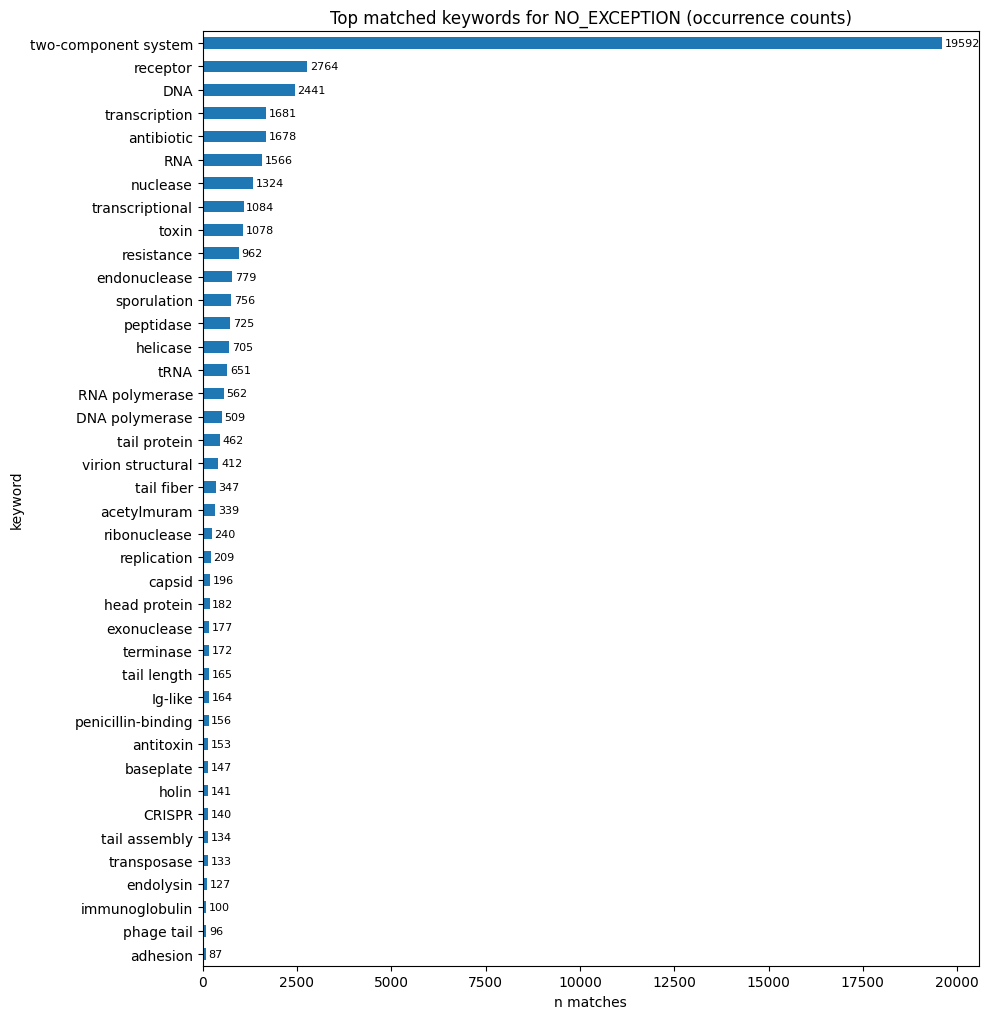

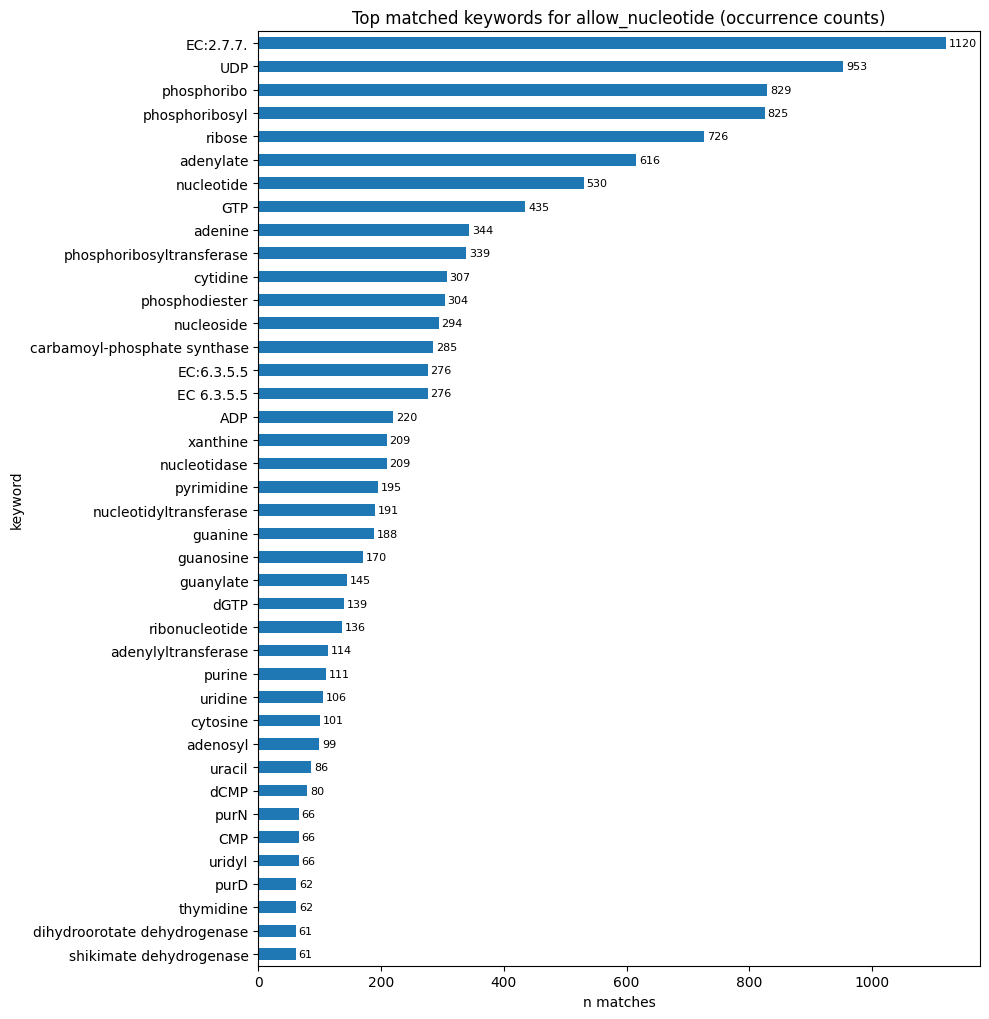

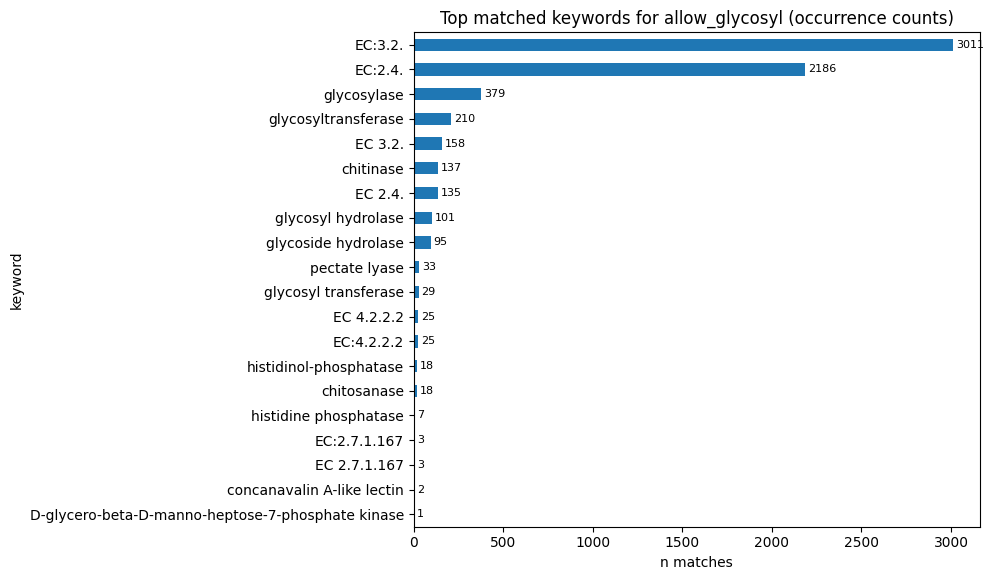

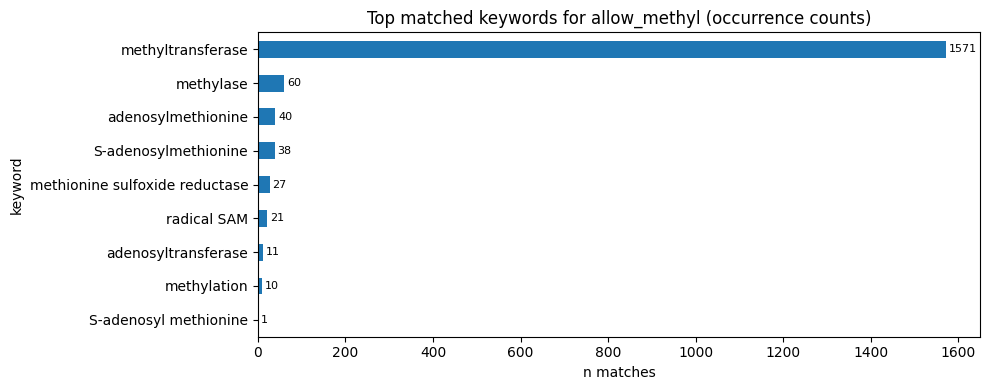

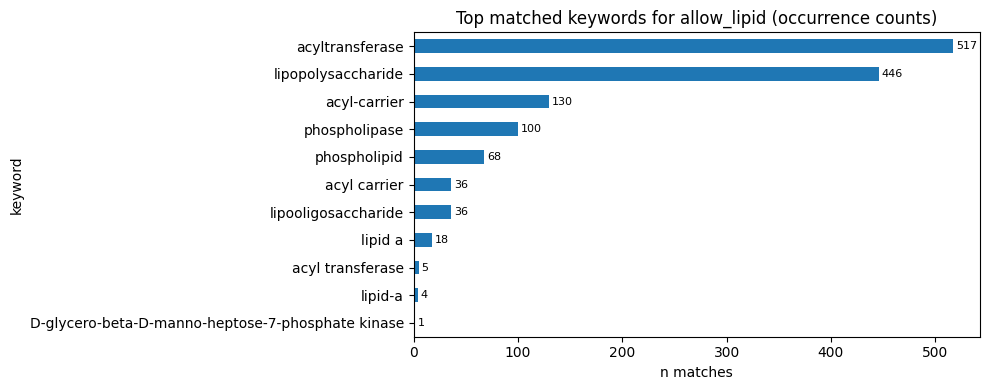

In [358]:
from collections import Counter

def plot_top_keywords_for_exception(df, exception, top_n=40, by="keyword"):
    # by: "keyword" or "mode" or "etype" (hard/soft)
    counts = Counter()
    for hits in df["keyword_matches"]:
        for (etype, exc, mode, kw) in hits:
            if exc != exception:
                continue
            if by == "keyword":
                counts[kw] += 1
            elif by == "mode":
                counts[mode] += 1
            elif by == "etype":
                counts[etype] += 1
            else:
                raise ValueError("by must be one of: keyword, mode, etype")

    if not counts:
        print(f"No matches for exception={exception}")
        return

    s = pd.Series(dict(counts)).sort_values(ascending=False).head(top_n)

    if by == "keyword":
        fig_h = max(4, 0.22 * len(s) + 1.5)
        fig, ax = plt.subplots(figsize=(10, fig_h))
        s.iloc[::-1].plot(kind="barh", ax=ax)
        ax.set_title(f"Top matched keywords for {exception} (occurrence counts)")
        ax.set_xlabel("n matches")
        ax.set_ylabel("keyword")
        add_bar_labels(ax)
        plt.tight_layout()
        plt.show()

# 1) one plot per exception: top keywords
for exc in EXCEPTIONS:
    plot_top_keywords_for_exception(df, exc, top_n=40, by="keyword")

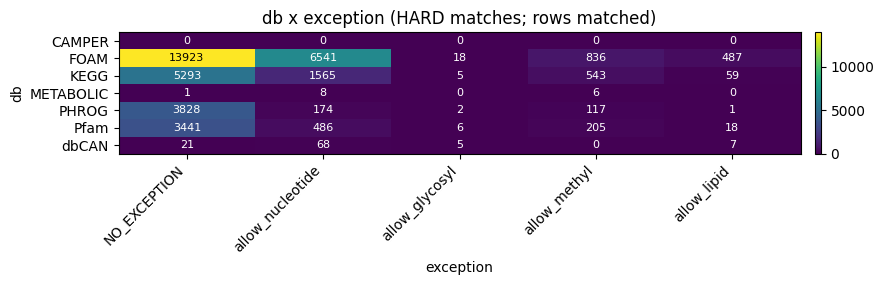

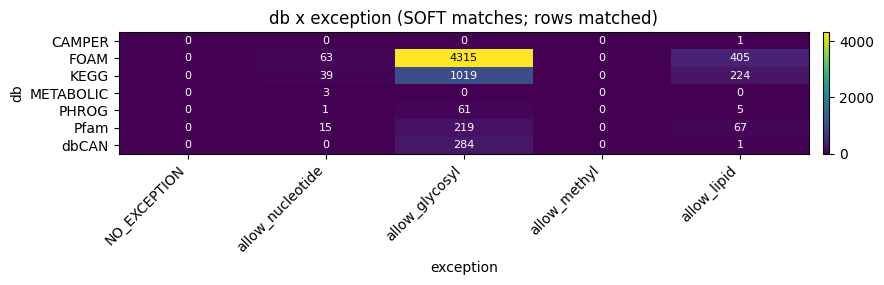

In [359]:
import numpy as np
import matplotlib.pyplot as plt

HARD_EXC_COLS = [f"hard_{e}" for e in EXCEPTIONS if f"hard_{e}" in df.columns]
SOFT_EXC_COLS = [f"soft_{e}" for e in EXCEPTIONS if f"soft_{e}" in df.columns]

db_hard = (
    df.groupby("db", dropna=False)[HARD_EXC_COLS]
    .sum()
    .astype(int)
    .sort_index()
)
db_hard.columns = [c.replace("hard_", "") for c in db_hard.columns]

db_soft = (
    df.groupby("db", dropna=False)[SOFT_EXC_COLS]
    .sum()
    .astype(int)
    .sort_index()
)
db_soft.columns = [c.replace("soft_", "") for c in db_soft.columns]

# align rows/cols
dbs = sorted(set(db_hard.index).union(set(db_soft.index)))
db_hard = db_hard.reindex(dbs).fillna(0).astype(int).reindex(columns=EXCEPTIONS, fill_value=0)
db_soft = db_soft.reindex(dbs).fillna(0).astype(int).reindex(columns=EXCEPTIONS, fill_value=0)

def plot_db_exception_heatmap(mat, title):
    fig, ax = plt.subplots(figsize=(9, 0.5 + 0.35 * len(mat)))
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("exception")
    ax.set_ylabel("db")
    ax.set_xticks(range(len(EXCEPTIONS)))
    ax.set_xticklabels(EXCEPTIONS, rotation=45, ha="right")
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)

    vmax = mat.values.max() if mat.size else 0
    thresh = vmax / 2 if vmax else 0

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = int(mat.iat[i, j])
            ax.text(j, i, str(v), ha="center", va="center", fontsize=8, color="black" if v > thresh else "white")

    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

plot_db_exception_heatmap(db_hard, "db x exception (HARD matches; rows matched)")
plot_db_exception_heatmap(db_soft, "db x exception (SOFT matches; rows matched)")

#### 5.1.3. Add more annotations using KEGG, FOAM, and PHROG classifications/categories

##### 5.1.3.1. Hard keywords with no exceptions
These should be known essential or common non-metabolic viral functions, but not too broad. Using KEGG and PHROG only, since FOAM doesn't include these.

**KEGG:**

In [360]:
ko_brite["A_name"].value_counts()

A_name
Brite Hierarchies                       22367
Human Diseases                          10447
Metabolism                               8941
Environmental Information Processing     6129
Organismal Systems                       6105
Not Included in Pathway or Brite         3781
Cellular Processes                       3508
Genetic Information Processing           2492
Name: count, dtype: int64

In [361]:
ko_essential = ko_brite[(ko_brite["A_name"] == "Genetic Information Processing") | (ko_brite["C_name"] == "Peptidoglycan biosynthesis [PATH:ko00550]")]
ko_essential = ko_essential[ko_essential["C_name"] != "Sulfur relay system [PATH:ko04122]"]
ko_essential

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
5415,K00790,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00550,Peptidoglycan biosynthesis [PATH:ko00550],ko00550,murA; UDP-N-acetylglucosamine 1-carboxyvinyltransferase [EC:2.5.1.7]
5416,K00075,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00550,Peptidoglycan biosynthesis [PATH:ko00550],ko00550,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
5417,K01924,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00550,Peptidoglycan biosynthesis [PATH:ko00550],ko00550,murC; UDP-N-acetylmuramate--alanine ligase [EC:6.3.2.8]
5418,K01925,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00550,Peptidoglycan biosynthesis [PATH:ko00550],ko00550,murD; UDP-N-acetylmuramoylalanine--D-glutamate ligase [EC:6.3.2.9]
5419,K23169,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00550,Peptidoglycan biosynthesis [PATH:ko00550],ko00550,murD2; UDP-N-acetylmuramoyl-L-alanine---L-glutamate ligase [EC:6.3.2.53]
...,...,...,...,...,...,...,...,...,...
11428,K26974,09120,Genetic Information Processing,09125,Information processing in viruses,03258,Virion - Bacteriophage lambda [PATH:ko03258],ko03258,L; Enterobacteria phage tail tip protein L
11429,K26975,09120,Genetic Information Processing,09125,Information processing in viruses,03258,Virion - Bacteriophage lambda [PATH:ko03258],ko03258,K; Enterobacteria phage tail tip assembly protein K
11430,K26976,09120,Genetic Information Processing,09125,Information processing in viruses,03258,Virion - Bacteriophage lambda [PATH:ko03258],ko03258,I; Enterobacteria phage tail tip assembly protein I
11431,K26977,09120,Genetic Information Processing,09125,Information processing in viruses,03258,Virion - Bacteriophage lambda [PATH:ko03258],ko03258,J; Enterobacteria phage tip attachment protein J


In [362]:
ko_essential["B_name"].value_counts()

B_name
Information processing in viruses     713
Translation                           511
Folding, sorting and degradation      490
Replication and repair                363
Transcription                         237
Chromosome                            149
Glycan biosynthesis and metabolism     55
Name: count, dtype: int64

In [363]:
pd.set_option('display.max_rows', 100)
ko_essential["C_name"].value_counts()

C_name
Ribosome [PATH:ko03010]                                             201
Protein processing in endoplasmic reticulum [PATH:ko04141]          145
Spliceosome [PATH:ko03040]                                          135
Ubiquitin mediated proteolysis [PATH:ko04120]                       133
Viral replication [PATH:ko03240]                                    130
Viral genome structure [PATH:ko03230]                               119
Nucleocytoplasmic transport [PATH:ko03013]                           98
ATP-dependent chromatin remodeling [PATH:ko03082]                    84
Ribosome biogenesis in eukaryotes [PATH:ko03008]                     83
RNA degradation [PATH:ko03018]                                       79
Homologous recombination [PATH:ko03440]                              72
Virion - Bacteriophages T4 and T7 [PATH:ko03259]                     68
Aminoacyl-tRNA biosynthesis [PATH:ko00970]                           66
RNA polymerase [PATH:ko03020]                            

In [364]:
pd.set_option('display.max_rows', 10)

In [365]:
ko_no_exception = set(ko_essential["KO"].tolist())
len(ko_no_exception)

2069

In [366]:
ko_no_exception_new = ko_no_exception - set(amg_filters["id"].to_list())
len(ko_no_exception_new)

1291

In [367]:
# Keep all KOs, not just new ones, because some of them might have been flagged under other rules but not this one
annots_add_no_exception_hard = ko_no_exception.copy()

**PHROG:**

In [368]:
phrog_annots["category"].value_counts()

category
unknown function                                     104106
tail                                                   1257
DNA, RNA and nucleotide metabolism                     1105
head and packaging                                      989
other                                                   580
moron, auxiliary metabolic gene and host takeover       468
transcription regulation                                337
lysis                                                   314
connector                                               139
integration and excision                                109
Name: count, dtype: int64

In [369]:
phrog_essential_df = phrog_annots[
    (phrog_annots["category"] == "tail") | (phrog_annots["category"] == "head and packaging") | (phrog_annots["category"] == "connector") |
    (phrog_annots["category"] == "integration and excision") | (phrog_annots["category"] == "transcription regulation") |
    (phrog_annots["category"] == "lysis")
    ]
phrog_essential = set(phrog_essential_df["phrog_id"].tolist())
len(phrog_essential)

3145

In [370]:
phrog_essential_new = phrog_essential - set(amg_filters["id"].to_list())
len(phrog_essential_new)

475

In [371]:
# Keep all PHROGs, not just new ones, because some of them might have been flagged under other rules but not this one
annots_add_no_exception_hard = annots_add_no_exception_hard | phrog_essential
len(annots_add_no_exception_hard)

5214

##### 5.1.3.2. Nucleotide metabolism

**KEGG:**

In [372]:
ko_brite_nucleotide = ko_brite[
    (ko_brite["B_name"]=="Nucleotide metabolism") | (ko_brite["C_name"]=="Nucleotide metabolism") | (ko_brite["C_name"]=="Biosynthesis of various nucleotide sugars")
    ]
ko_nucleotide = set(ko_brite_nucleotide["KO"].tolist())
len(ko_nucleotide)

303

In [373]:
len(ko_nucleotide & set(amg_filters["id"].to_list())), len(ko_nucleotide)

(240, 303)

In [374]:
ko_nucleotide_new = ko_nucleotide - set(amg_filters["id"].to_list())
len(ko_nucleotide_new)

63

In [375]:
ko_brite_no_nucleotide = ko_brite[
        (ko_brite["B_name"]!="Nucleotide metabolism") & (ko_brite["C_name"]!="Nucleotide metabolism") & (ko_brite["C_name"]!="Biosynthesis of various nucleotide sugars")
        ] # Should remove KOs that are specific to nucleotide metabolism but keep KOs that are cross-listed in both nucleotide and other metabolism categories
ko_nucleotide_only_nucleotide = ko_nucleotide - set(ko_brite_no_nucleotide["KO"].tolist()) # Remove nucleotide metabolism KOs that are cross-listed in other metabolism categories
len(ko_nucleotide_only_nucleotide)

154

These KOs that are only involved in nucleotide metabolism will be added as hard filters under the `allow_nucleotide` category.

In [376]:
# Keep all KOs, not just new ones, because some of them might have been flagged under other rules but not this one
annots_add_nucleotide_hard = ko_nucleotide_only_nucleotide.copy()

In [377]:
ko_nucleotide_cross_nucleotide = ko_nucleotide & set(ko_brite_no_nucleotide["KO"].tolist()) # nucleotide metabolism KOs that are cross-listed in other metabolism categories
len(ko_nucleotide_cross_nucleotide)

149

In [378]:
# Show KOs that are cross-listed in nucleotide metabolism and other metabolism categories, but hide nucleotide metabolism category annots since we know they are nucleotide metabolism related
pd.set_option('display.max_rows', 10)
ko_metabolism[(ko_metabolism["KO"].isin(ko_nucleotide_cross_nucleotide)) & (ko_metabolism["B_name"]!="Nucleotide metabolism")]

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
88,K01835,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,pgm; phosphoglucomutase [EC:5.4.2.2]
89,K15778,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,pmm-pgm; phosphomannomutase / phosphoglucomutase [EC:5.4.2.8 5.4.2.2]
90,K15779,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,PGM2; phosphoglucomutase / phosphopentomutase [EC:5.4.2.2 5.4.2.7]
203,K01839,09100,Metabolism,09101,Carbohydrate metabolism,00030,Pentose phosphate pathway [PATH:ko00030],ko00030,deoB; phosphopentomutase [EC:5.4.2.7]
204,K22199,09100,Metabolism,09101,Carbohydrate metabolism,00030,Pentose phosphate pathway [PATH:ko00030],ko00030,ppm; phosphopentomutase [EC:5.4.2.7]
...,...,...,...,...,...,...,...,...,...
8928,K13800,09100,Metabolism,09111,Xenobiotics biodegradation and metabolism,00983,Drug metabolism - other enzymes [PATH:ko00983],ko00983,"CMPK1, UMPK; UMP-CMP kinase [EC:2.7.4.14]"
8929,K10807,09100,Metabolism,09111,Xenobiotics biodegradation and metabolism,00983,Drug metabolism - other enzymes [PATH:ko00983],ko00983,RRM1; ribonucleoside-diphosphate reductase subunit M1 [EC:1.17.4.1]
8930,K10808,09100,Metabolism,09111,Xenobiotics biodegradation and metabolism,00983,Drug metabolism - other enzymes [PATH:ko00983],ko00983,RRM2; ribonucleoside-diphosphate reductase subunit M2 [EC:1.17.4.1]
8931,K00940,09100,Metabolism,09111,Xenobiotics biodegradation and metabolism,00983,Drug metabolism - other enzymes [PATH:ko00983],ko00983,"ndk, NME; nucleoside-diphosphate kinase [EC:2.7.4.6]"


In [379]:
pd.set_option('display.max_rows', 10)

These KOs that are cross listed under nucleotide metabolism and other categories will not be added, since they all seem to be phosphotransferases (and not phosphoribosyltransferases) and ureases, which seem more likely to be involved in non-nucleotide metabolism pathways, or they are already in the amg filter table.

**FOAM:**

In [380]:
foam_nucleotide_df = foam_hmm_named[foam_hmm_named["L1"]=="07_Nucleic acid metabolism"]
foam_nucleotide = set(foam_nucleotide_df["HMM"].tolist())
len(foam_nucleotide)

4622

In [381]:
len(foam_nucleotide & set(amg_filters["id"].to_list())), len(foam_nucleotide)

(3727, 4622)

In [382]:
foam_nucleotide_new = foam_nucleotide - set(amg_filters["id"].to_list())
len(foam_nucleotide_new)

895

In [383]:
foam_metab_no_nucleotide = foam_annots_metabolism[foam_annots_metabolism["L1"]!="07_Nucleic acid metabolism"] # Should remove HMMs that are specific to nucleotide metabolism but keep HMMs that are cross-listed in both nucleotide and other metabolism categories
foam_nucleotide_only_nucleotide = foam_nucleotide - set(foam_metab_no_nucleotide["HMM"].tolist()) # Remove nucleotide metabolism HMMs that are cross-listed in other metabolism categories
len(foam_nucleotide_only_nucleotide)

4024

In [384]:
pd.set_option('display.max_rows', 10)
foam_nucleotide_only_df = foam_annots_metabolism[foam_annots_metabolism["HMM"].isin(foam_nucleotide_only_nucleotide)]
foam_nucleotide_only_df = foam_nucleotide_only_df.drop(columns=["HMM", "HMM_N_KOs", "HMM_name"]).drop_duplicates().reset_index(drop=True) # deduplicate functions for multiple HMMs to simplify display
foam_nucleotide_only_df

,L1,L2,L3,L4,KO,Function,EC
0,07_Nucleic acid metabolism,Pyrimidine metabolism,NaN,NaN,K00207,DPYD; dihydropyrimidine dehydrogenase (NADP+),1.3.1.2
1,07_Nucleic acid metabolism,Pyrimidine metabolism,NaN,NaN,K00226,pyrD; dihydroorotate dehydrogenase (fumarate),1.3.98.1
2,07_Nucleic acid metabolism,Pyrimidine metabolism,NaN,NaN,K00254,"DHODH, pyrD; dihydroorotate dehydrogenase",1.3.5.2
3,07_Nucleic acid metabolism,Pyrimidine metabolism,NaN,NaN,K00524,"nrdJ; ribonucleotide reductase, class II",1.17.4.2
4,07_Nucleic acid metabolism,Pyrimidine metabolism,NaN,NaN,K00525,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain",1.17.4.1
...,...,...,...,...,...,...,...
345,07_Nucleic acid metabolism,Degradation of purine bases,NaN,NaN,K01487,"E3.5.4.3, guaD; guanine deaminase",3.5.4.3
346,07_Nucleic acid metabolism,Degradation of pyrimidine bases,NaN,NaN,K01466,allB; allantoinase,3.5.2.5
347,07_Nucleic acid metabolism,Degradation of pyrimidine bases,NaN,NaN,K01477,"alc, ALLC; allantoicase",3.5.3.4
348,07_Nucleic acid metabolism,Degradation of pyrimidine bases,NaN,NaN,K00758,"deoA, TYMP; thymidine phosphorylase",2.4.2.4


In [385]:
pd.set_option('display.max_rows', 10)

These FOAM HMMs that are only involved in nucleotide metabolism will be added as hard filters under the `allow_nucleotide` category.

In [386]:
# Keep all HMMs, not just new ones, because some of them might have been flagged under other rules but not this one
annots_add_nucleotide_hard = annots_add_nucleotide_hard | foam_nucleotide_only_nucleotide
len(annots_add_nucleotide_hard)

4178

In [387]:
foam_nucleotide_cross_nucleotide = foam_nucleotide & set(foam_metab_no_nucleotide["HMM"].tolist()) # new nucleotide metabolism HMMs that are cross-listed in other metabolism categories
len(foam_nucleotide_cross_nucleotide)

598

In [388]:
# Show FOAM HMMs that are cross-listed in nucleotide metabolism and other metabolism categories, but hide nucleotide metabolism category annots since we know they are nucleotide metabolism related
pd.set_option('display.max_rows', 10)
foam_nucleotide_cross_df = foam_annots_metabolism[(foam_annots_metabolism["HMM"].isin(foam_nucleotide_cross_nucleotide)) & (foam_annots_metabolism["L1"]!="07_Nucleic acid metabolism")]
foam_nucleotide_cross_df = foam_nucleotide_cross_df.drop(columns=["HMM", "HMM_N_KOs", "HMM_name"]).drop_duplicates().reset_index(drop=True) # deduplicate functions for multiple HMMs to simplify display
foam_nucleotide_cross_df

,L1,L2,L3,L4,KO,Function,EC
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K13830,ARO1; pentafunctional AROM polypeptide,4.2.3.4 4.2.1.10 1.1.1.25 2.7.1.71 2.5.1.19
1,01_Fermentation,Heterolactic fermentation,NaN,NaN,K13830,ARO1; pentafunctional AROM polypeptide,4.2.3.4 4.2.1.10 1.1.1.25 2.7.1.71 2.5.1.19
2,01_Fermentation,Lysine fermentation to acetate and butyrate,NaN,NaN,K01835,pgm; phosphoglucomutase,5.4.2.2
3,01_Fermentation,Homolactic fermentation,NaN,NaN,K01622,"K01622; fructose 1,6-bisphosphate aldolase/phosphatase",4.1.2.13 3.1.3.11
4,01_Fermentation,Homolactic fermentation,NaN,NaN,K13830,ARO1; pentafunctional AROM polypeptide,4.2.3.4 4.2.1.10 1.1.1.25 2.7.1.71 2.5.1.19
...,...,...,...,...,...,...,...
84,20_Hydrolysis of polymers,Starch,NaN,NaN,K01835,pgm; phosphoglucomutase,5.4.2.2
85,20_Hydrolysis of polymers,Xylose,NaN,NaN,K00963,"UGP2, galU, galF; UTP--glucose-1-phosphate uridylyltransferase",2.7.7.9
86,20_Hydrolysis of polymers,Mannose,NaN,NaN,K01840,manB; phosphomannomutase,5.4.2.8
87,20_Hydrolysis of polymers,Galactose,NaN,NaN,K01835,pgm; phosphoglucomutase,5.4.2.2


In [389]:
pd.set_option('display.max_rows', 10)

These are similar to the KEGG KOs that were cross-listed, so we will not be including these either for the same reasons.

**PHROG:**

In [390]:
pd.set_option('display.max_rows', 300)
phrog_nucleotide_df = phrog_annots[phrog_annots["category"]=="DNA, RNA and nucleotide metabolism"]
phrog_nucleotide_df["annot"].value_counts()

annot
HNH endonuclease                                                 125
DNA binding protein                                               82
DNA polymerase                                                    56
HTH DNA binding protein                                           56
replication initiation protein                                    48
endonuclease                                                      47
DNA primase                                                       44
exonuclease                                                       37
single strand DNA binding protein                                 31
DNA helicase                                                      26
ParB-like partition protein                                       17
thymidylate synthase                                              15
replication protein                                               15
RusA-like Holliday junction resolvase                             14
Holliday junction resolvase 

This PHROG category contains DNA/RNA replication and related functions mixed in with nucleotide metabolism functions. Since we treat these separately, they need to be separated.

In [391]:
phrog_nucleotide = set(phrog_nucleotide_df["phrog_id"].tolist())
phrog_nucleotide_new = phrog_nucleotide - set(amg_filters["id"].to_list())
len(phrog_nucleotide_new)

109

In [392]:
pd.set_option('display.max_rows', 300)
phrog_nucleotide_new_df = phrog_nucleotide_df[phrog_nucleotide_df["phrog_id"].isin(phrog_nucleotide_new)]
phrog_nucleotide_new_df["annot"].value_counts()

annot
RecT-like ssDNA annealing protein                               8
polymerase                                                      8
thioredoxin domain                                              6
Rnase H                                                         6
Erf-like ssDNA annealing protein                                6
primosomal protein                                              5
primase                                                         5
Mu Gam-like end protection                                      5
goF mRNA metabolism modulator                                   4
replisome organizer                                             4
partition protein                                               3
UmuD-like protein                                               3
single strand annealing protein                                 3
regulator of chromosome condensation                            3
Sir2 (NAD-dependent deacetylase)                                2
Sak-

In [393]:
pd.set_option('display.max_rows', 10)

Unlike KEGG and FOAM, PHROGs are not cross-listed to other categories. But it does seem like all of the PHROGs above that were not already present in the AMG filter table *should* be included for filtering, but not under the `allow_nucleotide` exception, rather they seem to all fit under the `NO_EXCEPTION` group, since they are all DNA/RNA replication related or have similar non-metabolic functions. They will be added as hard filter keywords under that group.

However, "thioredoxin domain" does seem to fit under the `allow_nucleotide` exception, so PHROGs with that annotation will be added as a hard filter under that category.

In [394]:
phrog_no_exception = set(phrog_nucleotide_new_df[phrog_nucleotide_new_df["annot"]!="thioredoxin domain"]["phrog_id"].tolist())
len(phrog_no_exception)

103

In [395]:
# Keep just the new PHROGs, because we don't want to mislabel nucleotide metabolism phrogs as no-exception if they were already included under other rules
annots_add_no_exception_hard = annots_add_no_exception_hard | phrog_no_exception
len(annots_add_no_exception_hard)

5317

In [396]:
# Keep just the new PHROGs, because we don't want to mislabel DNA/RNA replication PHROGs as nucleotide metabolism
phrog_nucleotide_hard = set(phrog_nucleotide_new_df[phrog_nucleotide_new_df["annot"]=="thioredoxin domain"]["phrog_id"].tolist())
len(phrog_nucleotide_hard)

6

In [397]:
annots_add_nucleotide_hard = annots_add_nucleotide_hard | phrog_nucleotide_hard
len(annots_add_nucleotide_hard)

4184

##### 5.1.3.3. Lipopolysaccharide and phospholipid metabolism
Only from KEGG, since the L2 category "Polysaccharide biosynthesis and assembly of cell surface structure" was excluded from the FOAM metabolic HMMs.

In [398]:
pd.set_option('display.max_rows', 20)
ko_brite[
    (ko_brite["B_name"]=="Lipid metabolism") | (ko_brite["C_name"]=="Ether lipid metabolism [PATH:ko00565]")
    ]["C_name"].value_counts()

C_name
Glycerophospholipid metabolism [PATH:ko00564]             118
Glycerolipid metabolism [PATH:ko00561]                     95
Fatty acid degradation [PATH:ko00071]                      60
Sphingolipid metabolism [PATH:ko00600]                     57
Arachidonic acid metabolism [PATH:ko00590]                 51
Steroid hormone biosynthesis [PATH:ko00140]                46
Fatty acid biosynthesis [PATH:ko00061]                     42
Mycolic acid biosynthesis [PATH:ko00074]                   36
Steroid biosynthesis [PATH:ko00100]                        34
Biosynthesis of unsaturated fatty acids [PATH:ko01040]     32
Ether lipid metabolism [PATH:ko00565]                      31
Linoleic acid metabolism [PATH:ko00591]                    27
alpha-Linolenic acid metabolism [PATH:ko00592]             26
Fatty acid elongation [PATH:ko00062]                       25
Cutin, suberine and wax biosynthesis [PATH:ko00073]        20
Primary bile acid biosynthesis [PATH:ko00120]              18
S

In [399]:
ko_brite_lipid = ko_brite[
    (ko_brite["C_name"]=="Lipopolysaccharide biosynthesis [PATH:ko00540]") |
    (ko_brite["C_name"]=="Glycerophospholipid metabolism [PATH:ko00564]")
    ]
ko_lipid = set(ko_brite_lipid["KO"].tolist())
len(ko_lipid)

168

In [400]:
ko_lipid_new = ko_lipid - set(amg_filters["id"].to_list())
len(ko_lipid_new)

58

In [401]:
pd.set_option('display.max_rows', 10)
ko_lipid_df = ko_metabolism[ko_metabolism["KO"].isin(ko_lipid)]
ko_lipid_df

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
1294,K01114,09100,Metabolism,09101,Carbohydrate metabolism,00562,Inositol phosphate metabolism [PATH:ko00562],ko00562,plc; phospholipase C [EC:3.1.4.3]
1295,K16619,09100,Metabolism,09101,Carbohydrate metabolism,00562,Inositol phosphate metabolism [PATH:ko00562],ko00562,"plc, cpa; phospholipase C / alpha-toxin [EC:3.1.4.3]"
1297,K00999,09100,Metabolism,09101,Carbohydrate metabolism,00562,Inositol phosphate metabolism [PATH:ko00562],ko00562,CDIPT; CDP-diacylglycerol--inositol 3-phosphatidyltransferase [EC:2.7.8.11]
2277,K16363,09100,Metabolism,09103,Lipid metabolism,00061,Fatty acid biosynthesis [PATH:ko00061],ko00061,lpxC-fabZ; UDP-3-O-[3-hydroxymyristoyl] N-acetylglucosamine deacetylase / 3-hydroxyacyl-[acyl-ca...
2350,K05939,09100,Metabolism,09103,Lipid metabolism,00071,Fatty acid degradation [PATH:ko00071],ko00071,aas; acyl-[acyl-carrier-protein]-phospholipid O-acyltransferase / long-chain-fatty-acid--[acyl-c...
...,...,...,...,...,...,...,...,...,...
5375,K03278,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00540,Lipopolysaccharide biosynthesis [PATH:ko00540],ko00540,"waaI, rfaI; UDP-D-galactose:(glucosyl)LPS alpha-1,3-D-galactosyltransferase [EC:2.4.1.44]"
5376,K03279,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00540,Lipopolysaccharide biosynthesis [PATH:ko00540],ko00540,"waaJ, rfaJ; UDP-glucose:(galactosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.58]"
5377,K00713,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00540,Lipopolysaccharide biosynthesis [PATH:ko00540],ko00540,"waaD; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]"
5378,K24623,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00540,Lipopolysaccharide biosynthesis [PATH:ko00540],ko00540,"waaH; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]"


In [402]:
pd.set_option('display.max_rows', 10)

These KOs will all be added as hard filters under the `allow_lipid` category.

In [403]:
# Keep all KOs, not just new ones, because some of them might have been flagged under other rules but not this one
annots_add_lipid_hard = ko_lipid_new.copy()

#### 5.1.4. Add new filters to the rest
Only hard filter keywords were made.

If any of the HMMs already exist in the amg filter table, their other exceptions will not change, but the columns corresponding to the exception for the set it is contained in will be updated.

If an HMM does not already exist in the table, just the hard filter columns for the exception set categories will be marked `True` and the rest will be `False`.

In [404]:
len(annots_add_no_exception_hard), len(annots_add_nucleotide_hard), len(annots_add_lipid_hard)

(5317, 4184, 58)

In [405]:
amgs_filters_add_no_exception = all_hmms[all_hmms["id"].isin(annots_add_no_exception_hard)]
amgs_filters_add_no_exception["hard_NO_EXCEPTION"] = True
amgs_filters_add_no_exception

/tmp/ipykernel_754746/357018252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amgs_filters_add_no_exception["hard_NO_EXCEPTION"] = True


,id,db,name,hard_NO_EXCEPTION
70,K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98],True
507,K00565,KEGG,RNMT; mRNA (guanine-N7-)-methyltransferase [EC:2.1.1.56],True
543,K00604,KEGG,"MTFMT, fmt; methionyl-tRNA formyltransferase [EC:2.1.2.9]",True
622,K00687,KEGG,"pbp2B, penA; penicillin-binding protein 2B",True
660,K00730,KEGG,OST4; dolichyl-diphosphooligosaccharide---protein glycosyltransferase subunit 4,True
...,...,...,...,...
162735,phrog_998,PHROG,endolysin,True
162769,phrog_9983,PHROG,tail protein,True
162813,phrog_9987,PHROG,holin,True
162846,phrog_999,PHROG,head vertex assembly chaperone,True


In [406]:
amgs_filters_add_nucleotide = all_hmms[all_hmms["id"].isin(annots_add_nucleotide_hard)]
amgs_filters_add_nucleotide["hard_allow_nucleotide"] = True
amgs_filters_add_nucleotide

/tmp/ipykernel_754746/3798506495.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amgs_filters_add_nucleotide["hard_allow_nucleotide"] = True


,id,db,name,hard_allow_nucleotide
68,K00073,KEGG,allD; ureidoglycolate dehydrogenase (NAD+) [EC:1.1.1.350],True
81,K00087,KEGG,"ygeS, xdhA; xanthine dehydrogenase molybdenum-binding subunit [EC:1.17.1.4]",True
205,K00226,KEGG,pyrD; dihydroorotate dehydrogenase (fumarate) [EC:1.3.98.1],True
230,K00254,KEGG,"DHODH, pyrD; dihydroorotate dehydrogenase [EC:1.3.5.2]",True
327,K00364,KEGG,"guaC, GMPR; GMP reductase [EC:1.7.1.7]",True
...,...,...,...,...
236974,HMMsoil99813,FOAM,"pnp, PNPT1; polyribonucleotide nucleotidyltransferase [EC:2.7.7.8]",True
236975,HMMsoil99815,FOAM,"UPB1, pydC; beta-ureidopropionase [EC:3.5.1.6]",True
236976,HMMsoil99817,FOAM,iunH; purine nucleosidase [EC:3.2.2.1],True
236983,HMMsoil99828,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1],True


In [407]:
amgs_filters_add_lipid = all_hmms[all_hmms["id"].isin(annots_add_lipid_hard)]
amgs_filters_add_lipid["hard_allow_lipid"] = True
amgs_filters_add_lipid

/tmp/ipykernel_754746/1237355628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amgs_filters_add_lipid["hard_allow_lipid"] = True


,id,db,name,hard_allow_lipid
5,K00006,KEGG,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8],True
52,K00057,KEGG,gpsA; glycerol-3-phosphate dehydrogenase (NAD(P)+) [EC:1.1.1.94],True
89,K00096,KEGG,"araM, egsA; glycerol-1-phosphate dehydrogenase [NAD(P)+] [EC:1.1.1.261]",True
98,K00105,KEGG,glpO; alpha-glycerophosphate oxidase [EC:1.1.3.21],True
103,K00111,KEGG,"glpA, glpD; glycerol-3-phosphate dehydrogenase [EC:1.1.5.3]",True
...,...,...,...,...
22376,K23083,KEGG,kdoH2; 3-deoxy-D-manno-octulosonic acid-hydrolase,True
22453,K23160,KEGG,"wabB, rfbU; GlcNAc transferase",True
24151,K24872,KEGG,yvoF; heptaprenylglycerol acetyltransferase [EC:2.3.1.-],True
24471,K25193,KEGG,SDC; serine decarboxylase [EC:4.1.1.-],True


In [408]:
import pandas as pd
import numpy as np

amg_filters_final = amg_filters.copy()

# Columns
ID_COLS = ["id", "db", "name"]
FLAG_COLS = [c for c in amg_filters_final.columns if c.startswith("hard_") or c.startswith("soft_")]

def _ensure_schema(df, flag_cols):
    out = df.copy()
    for c in flag_cols:
        if c not in out.columns:
            out[c] = False
    for c in flag_cols:
        out[c] = out[c].fillna(False).astype(bool)
    for c in ID_COLS:
        if c in out.columns:
            out[c] = out[c].fillna("")
    return out

amg_filters_final = _ensure_schema(amg_filters_final, FLAG_COLS)

updates = [
    amgs_filters_add_no_exception,
    amgs_filters_add_nucleotide,
    amgs_filters_add_lipid,
]

for upd in updates:
    upd = upd.copy()

    # determine which single hard_* column this update df carries (besides id/db/name)
    upd_flag_cols = [c for c in upd.columns if c.startswith("hard_") or c.startswith("soft_")]
    if len(upd_flag_cols) != 1:
        raise ValueError(f"Expected exactly 1 flag column in update df, found {upd_flag_cols}")
    upd_flag = upd_flag_cols[0]

    # normalize update df
    upd = _ensure_schema(upd, FLAG_COLS + [upd_flag])
    upd = upd[ID_COLS + [upd_flag]].drop_duplicates(subset=["id"], keep="last")

    # make sure upd_flag exists in master
    if upd_flag not in amg_filters_final.columns:
        amg_filters_final[upd_flag] = False
        FLAG_COLS.append(upd_flag)

    # left-merge update values into master
    tmp = amg_filters_final.merge(
        upd[["id", upd_flag]],
        on="id",
        how="left",
        suffixes=("", "_new"),
    )

    # update only the one exception column for rows present in upd
    tmp[upd_flag] = tmp[upd_flag] | tmp[f"{upd_flag}_new"].fillna(False).astype(bool)
    tmp = tmp.drop(columns=[f"{upd_flag}_new"])

    # add brand-new ids that aren't already in master
    missing = upd.loc[~upd["id"].isin(tmp["id"]), :].copy()
    if not missing.empty:
        # initialize all flags false
        for c in FLAG_COLS:
            if c not in missing.columns:
                missing[c] = False
        # set only the update flag True (respecting whatever upd contains; typically True)
        missing[upd_flag] = missing[upd_flag].fillna(False).astype(bool)

        missing = missing[ID_COLS + FLAG_COLS]
        tmp = pd.concat([tmp, missing], ignore_index=True)

    amg_filters_final = tmp

# Final rule: within each exception, hard overrides soft (only within same exception)
exceptions = sorted({c.replace("hard_", "").replace("soft_", "") for c in FLAG_COLS})
for exc in exceptions:
    hcol = f"hard_{exc}"
    scol = f"soft_{exc}"
    if hcol in amg_filters_final.columns and scol in amg_filters_final.columns:
        amg_filters_final.loc[amg_filters_final[hcol].fillna(False).astype(bool), scol] = False

# clean types
for c in FLAG_COLS:
    amg_filters_final[c] = amg_filters_final[c].fillna(False).astype(bool)

amg_filters_final = amg_filters_final.sort_values(["db", "id"]).reset_index(drop=True)
amg_filters_final

/tmp/ipykernel_754746/310942554.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp[upd_flag] = tmp[upd_flag] | tmp[f"{upd_flag}_new"].fillna(False).astype(bool)
/tmp/ipykernel_754746/310942554.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp[upd_flag] = tmp[upd_flag] | tmp[f"{upd_flag}_new"].fillna(False).astype(bool)
/tmp/ipykernel_754746/310942554.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to th

,id,db,name,hard_NO_EXCEPTION,soft_NO_EXCEPTION,hard_allow_glycosyl,soft_allow_glycosyl,hard_allow_nucleotide,soft_allow_nucleotide,hard_allow_methyl,soft_allow_methyl,hard_allow_lipid,soft_allow_lipid
0,K00632,CAMPER,acetyl-CoA acyltransferase [EC:2.3.1.16],False,False,False,False,False,False,False,False,False,True
1,HMMsoil100009,FOAM,ramA; alpha-L-rhamnosidase [EC:3.2.1.40],False,False,False,True,False,False,False,False,False,False
2,HMMsoil10002,FOAM,METTL6; tRNA N(3)-methylcytidine methyltransferase METTL6 [EC:2.1.1.-],True,False,False,False,True,False,True,False,False,False
3,HMMsoil10003,FOAM,METTL6; tRNA N(3)-methylcytidine methyltransferase METTL6 [EC:2.1.1.-],True,False,False,False,True,False,True,False,False,False
4,HMMsoil100035,FOAM,"phoR; two-component system, OmpR family, phosphate regulon sensor histidine kinase PhoR [EC:2.7....",True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43150,PL10,dbCAN,pectate lyase (EC 4.2.2.2),False,False,True,False,False,False,False,False,False,False
43151,PL2,dbCAN,pectate lyase (EC 4.2.2.2); exo-polygalacturonate lyase (EC 4.2.2.9).,False,False,True,False,False,False,False,False,False,False
43152,PL3,dbCAN,pectate lyase (EC 4.2.2.2).,False,False,True,False,False,False,False,False,False,False
43153,PL42,dbCAN,"L-rhamnose-alpha-1,4-D-glucuronate lyase (EC 4.2.2.-); L-Rhalpha-alpha-1,4-GlcA alpha-L-rhamnohy...",False,False,False,True,False,False,False,False,False,False


In [409]:
len(amg_filters), len(amg_filters_final)

(40461, 43155)

In [410]:
amg_filters_final.to_csv("../CheckAMG/files/AMG_filters.tsv", sep="\t", index=False)

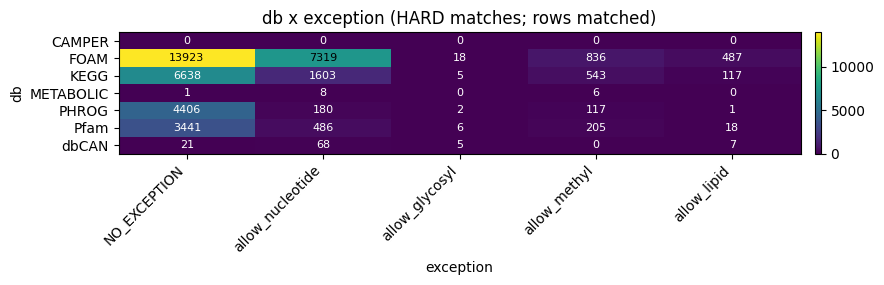

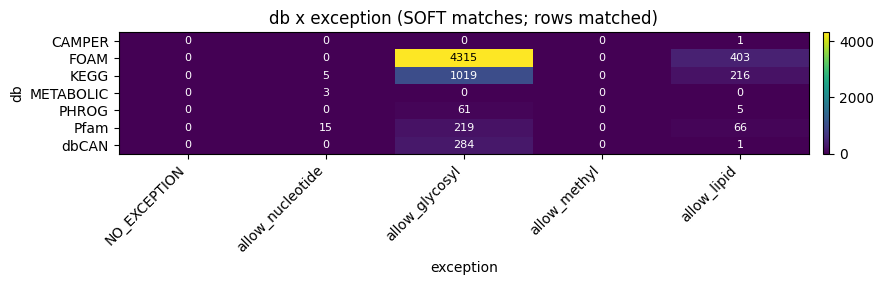

In [411]:
import numpy as np
import matplotlib.pyplot as plt

df = amg_filters_final.copy()

HARD_EXC_COLS = [f"hard_{e}" for e in EXCEPTIONS if f"hard_{e}" in df.columns]
SOFT_EXC_COLS = [f"soft_{e}" for e in EXCEPTIONS if f"soft_{e}" in df.columns]

db_hard = (
    df.groupby("db", dropna=False)[HARD_EXC_COLS]
    .sum()
    .astype(int)
    .sort_index()
)
db_hard.columns = [c.replace("hard_", "") for c in db_hard.columns]

db_soft = (
    df.groupby("db", dropna=False)[SOFT_EXC_COLS]
    .sum()
    .astype(int)
    .sort_index()
)
db_soft.columns = [c.replace("soft_", "") for c in db_soft.columns]

# align rows/cols
dbs = sorted(set(db_hard.index).union(set(db_soft.index)))
db_hard = db_hard.reindex(dbs).fillna(0).astype(int).reindex(columns=EXCEPTIONS, fill_value=0)
db_soft = db_soft.reindex(dbs).fillna(0).astype(int).reindex(columns=EXCEPTIONS, fill_value=0)

def plot_db_exception_heatmap(mat, title):
    fig, ax = plt.subplots(figsize=(9, 0.5 + 0.35 * len(mat)))
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("exception")
    ax.set_ylabel("db")
    ax.set_xticks(range(len(EXCEPTIONS)))
    ax.set_xticklabels(EXCEPTIONS, rotation=45, ha="right")
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)

    vmax = mat.values.max() if mat.size else 0
    thresh = vmax / 2 if vmax else 0

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = int(mat.iat[i, j])
            ax.text(j, i, str(v), ha="center", va="center", fontsize=8, color="black" if v > thresh else "white")

    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

plot_db_exception_heatmap(db_hard, "db x exception (HARD matches; rows matched)")
plot_db_exception_heatmap(db_soft, "db x exception (SOFT matches; rows matched)")

### 5.2. False APG table
This should be pretty straightforward, just hard, no-exception filters related to structural, packaging, or surface proteins.

In [412]:
HARD_KEYWORDS_DICT_PHYS = {
    "NO_EXCEPTION": {
        "substring" : [
            "baseplate", "capsid", "portal", "receptor", "sheath", "virion structure", "virion structural",
            "head decoration", "head morphogenesis", "head protein", "head vertex", "phage head",
            "tail assembly", "tail fiber", "tail fibre", "tail length", "tail peptide", "tail protein", "tail spike", "tail terminator", "phage tail",
            "immunoglobulin", "terminase",
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_nucleotide": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_glycosyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [], 
        "case_sensitive_whole_word" : [],
    },
    "allow_methyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_lipid": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

SOFT_KEYWORDS_DICT_PHYS = {
    "NO_EXCEPTION": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_nucleotide": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_glycosyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [], 
        "case_sensitive_whole_word" : [],
    },
    "allow_methyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_lipid": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

In [413]:
flagged_hmms_phys = flag_hmms_with_keywords(all_hmms, HARD_KEYWORDS_DICT_PHYS, SOFT_KEYWORDS_DICT_PHYS)
flagged_hmms_phys

,id,db,name,keyword_matches,n_total_matches,matched_exception_types,matched_exceptions,matched_modes,matched_keywords,first_exception_type,...,hard_allow_methyl,soft_allow_methyl,allow_methyl,hard_allow_nucleotide,soft_allow_nucleotide,allow_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
827,K00910,KEGG,"ADRBK, GRK; beta-adrenergic-receptor kinase [EC:2.7.11.15]","[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
841,K00924,KEGG,TMK; receptor protein kinase TMK [EC:2.7.11.1],"[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
2123,K02296,KEGG,"ARNTL, BMAL1, CYC; aryl hydrocarbon receptor nuclear translocator-like protein 1","[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
2200,K02374,KEGG,"PTPN13, FAP-1; tyrosine-protein phosphatase non-receptor type 13","[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
2403,K02583,KEGG,"NGFR, TNFRSF16, CD271; tumor necrosis factor receptor superfamily member 16","[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233977,HMMsoil94062,FOAM,RIPK2; receptor-interacting serine/threonine-protein kinase 2 [EC:2.7.11.1]; RIPK3; receptor-int...,"[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
234808,HMMsoil95666,FOAM,IRAK1; interleukin-1 receptor-associated kinase 1 [EC:2.7.11.1]; IRAK2; interleukin-1 receptor-a...,"[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
236549,HMMsoil99003,FOAM,BAK1; brassinosteroid insensitive 1-associated receptor kinase 1 [EC:2.7.10.1] [EC:2.7.11.1]; SE...,"[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False
236839,HMMsoil99570,FOAM,IRAK4; interleukin-1 receptor-associated kinase 4 [EC:2.7.11.1],"[(hard, NO_EXCEPTION, substring, receptor)]",1,hard,NO_EXCEPTION,substring,receptor,hard,...,False,False,False,False,False,False,1,True,False,False


In [414]:
apg_filters = flagged_hmms_phys[
    [
        "id", "db", "name",
        "hard_NO_EXCEPTION", "soft_NO_EXCEPTION",
        "hard_allow_glycosyl", "soft_allow_glycosyl",
        "hard_allow_nucleotide", "soft_allow_nucleotide",
        "hard_allow_methyl", "soft_allow_methyl",
        "hard_allow_lipid", "soft_allow_lipid",
        ]
    ]
apg_filters

,id,db,name,hard_NO_EXCEPTION,soft_NO_EXCEPTION,hard_allow_glycosyl,soft_allow_glycosyl,hard_allow_nucleotide,soft_allow_nucleotide,hard_allow_methyl,soft_allow_methyl,hard_allow_lipid,soft_allow_lipid
827,K00910,KEGG,"ADRBK, GRK; beta-adrenergic-receptor kinase [EC:2.7.11.15]",True,False,False,False,False,False,False,False,False,False
841,K00924,KEGG,TMK; receptor protein kinase TMK [EC:2.7.11.1],True,False,False,False,False,False,False,False,False,False
2123,K02296,KEGG,"ARNTL, BMAL1, CYC; aryl hydrocarbon receptor nuclear translocator-like protein 1",True,False,False,False,False,False,False,False,False,False
2200,K02374,KEGG,"PTPN13, FAP-1; tyrosine-protein phosphatase non-receptor type 13",True,False,False,False,False,False,False,False,False,False
2403,K02583,KEGG,"NGFR, TNFRSF16, CD271; tumor necrosis factor receptor superfamily member 16",True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233977,HMMsoil94062,FOAM,RIPK2; receptor-interacting serine/threonine-protein kinase 2 [EC:2.7.11.1]; RIPK3; receptor-int...,True,False,False,False,False,False,False,False,False,False
234808,HMMsoil95666,FOAM,IRAK1; interleukin-1 receptor-associated kinase 1 [EC:2.7.11.1]; IRAK2; interleukin-1 receptor-a...,True,False,False,False,False,False,False,False,False,False
236549,HMMsoil99003,FOAM,BAK1; brassinosteroid insensitive 1-associated receptor kinase 1 [EC:2.7.10.1] [EC:2.7.11.1]; SE...,True,False,False,False,False,False,False,False,False,False
236839,HMMsoil99570,FOAM,IRAK4; interleukin-1 receptor-associated kinase 4 [EC:2.7.11.1],True,False,False,False,False,False,False,False,False,False


In [415]:
apg_filters.to_csv("../CheckAMG/files/APG_filters.tsv", sep="\t", index=False)

### 5.3. False AReG table
Still retain annotations if the keywords 'regulation', 'regualtory', or 'regulator' are also present.

In [416]:
HARD_KEYWORDS_DICT_REG = {
    "NO_EXCEPTION": {
        "substring" : [
            # Structural/surface/cell entry proteins
            "baseplate", "capsid", "portal", "receptor", "sheath", "virion structure", "virion structural",
            "head decoration", "head morphogenesis", "head protein", "head vertex", "phage head",
            "tail assembly", "tail fiber", "tail fibre", "tail length", "tail peptide", "tail protein", "tail spike", "tail terminator", "phage tail",
            "immunoglobulin", "terminase",
            # DNA/RNA replication and nuclease activity but not gene regulation
            "nuclease", "replication",
            "ribonuclease", "EC:3.1.26.", "EC 3.1.26.", "EC:3.1.27.", "EC 3.1.27.",
            "deoxyribonuclease", "EC:3.1.21.", "EC 3.1.21.", "EC:3.1.22.", "EC 3.1.22.",
            "exonuclease", "endonuclease",
            "recombinase", "recombination", "integrase", "integration", "excisionase", "resolvase", "helicase",
            "transposase", "transposition", "transposon",
            "DNA ligase",  "RNA ligase", "DNA polymerase", "RNA polymerase",
            "primase", "topoisomerase", "gyrase",
            # Often related to DNA modification rather than gene regulation
            "adenosyltransferase", "radical SAM",
            "methyltransferase", "methylation", "EC: 2.1.", "EC 2.1.",
            "methionine sulfoxide reductase", "methionine-sulfoxide reductase",
            "S-adenosylmethionine", "S-adenosyl methionine", "adenosylmethionine",
            # Involved in adaptive immunity, not in direct gene regulation
            "CRISPR", "spacer",
            # General, not specific to regulation
            "adaptation", 
        ],
        "case_sensitive" : [],
        "whole_word" : [
            # Commonly associated with restriction-modification systems, not gene regulation
            "methylase", # Don't want to exclude "demethylase"
            ],
        "case_sensitive_whole_word" : [],
    },
    "allow_nucleotide": { # This won't be used as an actual filter, it will just be a way to mark annotations that we want to rescue
        "substring" : [
            "regulatory", "regulation", "regulator"
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_glycosyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [], 
        "case_sensitive_whole_word" : [],
    },
    "allow_methyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_lipid": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

SOFT_KEYWORDS_DICT_REG = {
    "NO_EXCEPTION": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_nucleotide": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_glycosyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [], 
        "case_sensitive_whole_word" : [],
    },
    "allow_methyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "allow_lipid": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

In [417]:
flagged_hmms_reg = flag_hmms_with_keywords(all_hmms, HARD_KEYWORDS_DICT_REG, SOFT_KEYWORDS_DICT_REG)
flagged_hmms_reg

,id,db,name,keyword_matches,n_total_matches,matched_exception_types,matched_exceptions,matched_modes,matched_keywords,first_exception_type,...,hard_allow_methyl,soft_allow_methyl,allow_methyl,hard_allow_nucleotide,soft_allow_nucleotide,allow_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
166,K00182,KEGG,"WNT2; wingless-type MMTV integration site family, member 2","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
282,K00312,KEGG,"WNT3; wingless-type MMTV integration site family, member 3","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase,"[(hard, allow_nucleotide, substring, regulator)]",1,hard,allow_nucleotide,substring,regulator,hard,...,False,False,False,True,False,True,1,True,False,False
361,K00408,KEGG,"WNT4; wingless-type MMTV integration site family, member 4","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
393,K00444,KEGG,"WNT5; wingless-type MMTV integration site family, member 5","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236986,HMMsoil99831,FOAM,"glnL, ntrB; two-component system, NtrC family, nitrogen regulation sensor histidine kinase GlnL ...","[(hard, allow_nucleotide, substring, regulation)]",1,hard,allow_nucleotide,substring,regulation,hard,...,False,False,False,True,False,True,1,True,False,False
237009,HMMsoil99877,FOAM,"metH, MTR; 5-methyltetrahydrofolate--homocysteine methyltransferase [EC:2.1.1.13]","[(hard, NO_EXCEPTION, substring, methyltransferase)]",1,hard,NO_EXCEPTION,substring,methyltransferase,hard,...,False,False,False,False,False,False,1,True,False,False
237020,HMMsoil99891,FOAM,"K11527; two-component system, sensor histidine kinase and response regulator [EC:2.7.13.3]","[(hard, allow_nucleotide, substring, regulator)]",1,hard,allow_nucleotide,substring,regulator,hard,...,False,False,False,True,False,True,1,True,False,False
237041,HMMsoil99924,FOAM,"ubiE; demethylmenaquinone methyltransferase / 2-methoxy-6-polyprenyl-1,4-benzoquinol methylase [...","[(hard, NO_EXCEPTION, substring, methyltransferase), (hard, NO_EXCEPTION, whole_word, methylase)]",2,hard,NO_EXCEPTION,substring; whole_word,methylase; methyltransferase,hard,...,False,False,False,False,False,False,1,True,True,False


In [418]:
# Rescue flagged annotations that also contain "regulation" using the `allow_nucleotide` category
mask = flagged_hmms_reg["hard_allow_nucleotide"].fillna(False).astype(bool)
flagged_hmms_reg.loc[mask, "hard_NO_EXCEPTION"] = False
flagged_hmms_reg.loc[mask, "hard_allow_nucleotide"] = False
flagged_hmms_reg

,id,db,name,keyword_matches,n_total_matches,matched_exception_types,matched_exceptions,matched_modes,matched_keywords,first_exception_type,...,hard_allow_methyl,soft_allow_methyl,allow_methyl,hard_allow_nucleotide,soft_allow_nucleotide,allow_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
166,K00182,KEGG,"WNT2; wingless-type MMTV integration site family, member 2","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
282,K00312,KEGG,"WNT3; wingless-type MMTV integration site family, member 3","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase,"[(hard, allow_nucleotide, substring, regulator)]",1,hard,allow_nucleotide,substring,regulator,hard,...,False,False,False,False,False,True,1,True,False,False
361,K00408,KEGG,"WNT4; wingless-type MMTV integration site family, member 4","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
393,K00444,KEGG,"WNT5; wingless-type MMTV integration site family, member 5","[(hard, NO_EXCEPTION, substring, integration)]",1,hard,NO_EXCEPTION,substring,integration,hard,...,False,False,False,False,False,False,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236986,HMMsoil99831,FOAM,"glnL, ntrB; two-component system, NtrC family, nitrogen regulation sensor histidine kinase GlnL ...","[(hard, allow_nucleotide, substring, regulation)]",1,hard,allow_nucleotide,substring,regulation,hard,...,False,False,False,False,False,True,1,True,False,False
237009,HMMsoil99877,FOAM,"metH, MTR; 5-methyltetrahydrofolate--homocysteine methyltransferase [EC:2.1.1.13]","[(hard, NO_EXCEPTION, substring, methyltransferase)]",1,hard,NO_EXCEPTION,substring,methyltransferase,hard,...,False,False,False,False,False,False,1,True,False,False
237020,HMMsoil99891,FOAM,"K11527; two-component system, sensor histidine kinase and response regulator [EC:2.7.13.3]","[(hard, allow_nucleotide, substring, regulator)]",1,hard,allow_nucleotide,substring,regulator,hard,...,False,False,False,False,False,True,1,True,False,False
237041,HMMsoil99924,FOAM,"ubiE; demethylmenaquinone methyltransferase / 2-methoxy-6-polyprenyl-1,4-benzoquinol methylase [...","[(hard, NO_EXCEPTION, substring, methyltransferase), (hard, NO_EXCEPTION, whole_word, methylase)]",2,hard,NO_EXCEPTION,substring; whole_word,methylase; methyltransferase,hard,...,False,False,False,False,False,False,1,True,True,False


In [419]:
areg_filters = flagged_hmms_reg[
    [
        "id", "db", "name",
        "hard_NO_EXCEPTION", "soft_NO_EXCEPTION",
        "hard_allow_glycosyl", "soft_allow_glycosyl",
        "hard_allow_nucleotide", "soft_allow_nucleotide",
        "hard_allow_methyl", "soft_allow_methyl",
        "hard_allow_lipid", "soft_allow_lipid",
        ]
    ]

# Remove rows that have no remaining flags / all are false
bool_cols = areg_filters.select_dtypes(include="bool").columns
areg_filters = areg_filters.loc[
    areg_filters[bool_cols].any(axis=1)
].reset_index(drop=True)

areg_filters

,id,db,name,hard_NO_EXCEPTION,soft_NO_EXCEPTION,hard_allow_glycosyl,soft_allow_glycosyl,hard_allow_nucleotide,soft_allow_nucleotide,hard_allow_methyl,soft_allow_methyl,hard_allow_lipid,soft_allow_lipid
0,K00182,KEGG,"WNT2; wingless-type MMTV integration site family, member 2",True,False,False,False,False,False,False,False,False,False
1,K00312,KEGG,"WNT3; wingless-type MMTV integration site family, member 3",True,False,False,False,False,False,False,False,False,False
2,K00408,KEGG,"WNT4; wingless-type MMTV integration site family, member 4",True,False,False,False,False,False,False,False,False,False
3,K00444,KEGG,"WNT5; wingless-type MMTV integration site family, member 5",True,False,False,False,False,False,False,False,False,False
4,K00445,KEGG,"WNT6; wingless-type MMTV integration site family, member 6",True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9562,HMMsoil99583,FOAM,"rhlB; ATP-dependent RNA helicase RhlB [EC:3.6.4.13]; deaD, cshA; ATP-dependent RNA helicase DeaD...",True,False,False,False,False,False,False,False,False,False
9563,HMMsoil99686,FOAM,E2.1.1.104; caffeoyl-CoA O-methyltransferase [EC:2.1.1.104],True,False,False,False,False,False,False,False,False,False
9564,HMMsoil99877,FOAM,"metH, MTR; 5-methyltetrahydrofolate--homocysteine methyltransferase [EC:2.1.1.13]",True,False,False,False,False,False,False,False,False,False
9565,HMMsoil99924,FOAM,"ubiE; demethylmenaquinone methyltransferase / 2-methoxy-6-polyprenyl-1,4-benzoquinol methylase [...",True,False,False,False,False,False,False,False,False,False


In [420]:
areg_filters.to_csv("../CheckAMG/files/AReG_filters.tsv", sep="\t", index=False)

## 6. Check for overlap between AMG, APG, and AReG tables and resolve

### 6.1. Between APGs and AReGs

In [421]:
overlap_aregs_apgs = pd.merge(AReGs, APGs, how='inner', on=['id', 'db', 'name'])
pd.set_option('display.max_rows', 500)
overlap_aregs_apgs["name"].unique()

array(['flhC; flagellar transcriptional activator FlhC',
       'flhD; flagellar transcriptional activator FlhD',
       'fliS; flagellar secretion chaperone FliS',
       'spo0F; two-component system, response regulator, stage 0 sporulation protein F',
       'kinA; two-component system, sporulation sensor kinase A [EC:2.7.13.3]',
       'pilG; twitching motility two-component system response regulator PilG',
       'pilH; twitching motility two-component system response regulator PilH',
       'ctsR; transcriptional regulator of stress and heat shock response',
       'spoVT; AbrB family transcriptional regulator, stage V sporulation protein T',
       'bolA; BolA family transcriptional regulator, general stress-responsive regulator',
       'spoIIID; putative DeoR family transcriptional regulator, stage III sporulation protein D',
       'rapA, spo0L; response regulator aspartate phosphatase A (stage 0 sporulation protein L) [EC:3.1.-.-]',
       'spo0E; stage 0 sporulation regulato

Upon inspection, it looks like all of these may fit better at AReGs as opposed to APGs.

In [422]:
APGs_filtered = APGs[~APGs["name"].isin(overlap_aregs_apgs["name"])]
pd.set_option('display.max_rows', 20)
APGs_filtered

,id,db,name
1826,K01993,KEGG,ABC-2.TX; HlyD family secretion protein
1838,K02005,KEGG,ABC.CD.TX; HlyD family secretion protein
1855,K02022,KEGG,ABC.MR.TX; HlyD family secretion protein
2207,K02382,KEGG,flbA; flagellar protein FlbA
2208,K02383,KEGG,flbB; flagellar protein FlbB
...,...,...,...
234572,HMMsoil9519,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24]
234816,HMMsoil95682,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...
235145,HMMsoil96343,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system..."
235608,HMMsoil97222,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."


In [423]:
overlap_aregs_apgs_filtered = pd.merge(AReGs, APGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_aregs_apgs_filtered

,id,db,name


### 6.2. Between AReGs and AMGs

In [424]:
overlap_aregs_amgs = pd.merge(AReGs, amg_table, how='inner', on=['id', 'db', 'name'])
pd.set_option('display.max_rows', 500)
overlap_aregs_amgs

,id,db,name,V-score,VL-score
0,K00610,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit,0.03,0.477121
1,K01846,KEGG,"glmS, mutS, mamA; methylaspartate mutase sigma subunit [EC:5.4.99.1]",0.10,1.000000
2,K02502,KEGG,hisZ; ATP phosphoribosyltransferase regulatory subunit,1.18,2.071882
3,K02716,KEGG,psbO; photosystem II oxygen-evolving enhancer protein 1,NaN,NaN
4,K02717,KEGG,psbP; photosystem II oxygen-evolving enhancer protein 2,NaN,NaN
5,K02825,KEGG,pyrR; pyrimidine operon attenuation protein / uracil phosphoribosyltransferase [EC:2.4.2.9],0.87,1.939519
6,K03524,KEGG,"birA; BirA family transcriptional regulator, biotin operon repressor / biotin---[acetyl-CoA-carb...",0.17,1.230449
7,K03533,KEGG,torD; TorA specific chaperone,0.04,0.602060
8,K03707,KEGG,tenA; thiaminase (transcriptional activator TenA) [EC:3.5.99.2],0.09,0.954243
9,K04462,KEGG,"MECOM, EVI1, PRDM3; [histone H3]-lysine9 N-methyltransferase (ecotropic virus integration site 1...",1.00,2.000000


These all look like they should be AReGs and not AMGs, **except for:**
- `glmS, mutS, mamA; methylaspartate mutase sigma subunit [EC:5.4.99.1]`
- `psbO; photosystem II oxygen-evolving enhancer protein 1`
- `psbP; photosystem II oxygen-evolving enhancer protein 2`
- `psbQ; photosystem II oxygen-evolving enhancer protein 3`
- `actVA5; two-component flavin-dependent monooxygenase [EC:1.14.14.-]`
- `methane monooxygenase regulatory protein B`
- `hisZ; ATP phosphoribosyltransferase regulatory subunit`
- `mmoB; methane monooxygenase regulatory protein B`

In [425]:
allowed_functions = [
    "glmS, mutS, mamA; methylaspartate mutase sigma subunit [EC:5.4.99.1]",
    "psbO; photosystem II oxygen-evolving enhancer protein 1",
    "psbP; photosystem II oxygen-evolving enhancer protein 2",
    "psbQ; photosystem II oxygen-evolving enhancer protein 3",
    "actVA5; two-component flavin-dependent monooxygenase [EC:1.14.14.-]",
    "methane monooxygenase regulatory protein B",
    "hisZ; ATP phosphoribosyltransferase regulatory subunit",
    "mmoB; methane monooxygenase regulatory protein B"
]
AMGs_filtered = amg_table[
    ~amg_table["name"].isin(
        overlap_aregs_amgs[~overlap_aregs_amgs["name"].isin(allowed_functions)]["name"]
    )
]
AMGs_filtered = AMGs_filtered.reset_index(drop=True)
pd.set_option('display.max_rows', 10)
AMGs_filtered

,id,V-score,VL-score,db,name
0,K00558,10.0,4.626063,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
1,K00525,10.0,4.252343,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
2,K03465,10.0,4.202434,KEGG,"thyX, thy1; thymidylate synthase (FAD) [EC:2.1.1.148]"
3,K19002,10.0,4.167613,KEGG,"mgs, bgsB; 1,2-diacylglycerol 3-alpha-glucosyltransferase [EC:2.4.1.337]"
4,K01784,10.0,4.143452,KEGG,"galE, GALE; UDP-glucose 4-epimerase [EC:5.1.3.2]"
...,...,...,...,...,...
62289,PL5,NaN,NaN,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
62290,PL6,NaN,NaN,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
62291,PL7,NaN,NaN,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
62292,PL8,NaN,NaN,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [426]:
AReGs_filtered = AReGs[~AReGs["name"].isin(allowed_functions)]
pd.set_option('display.max_rows', 10)
AReGs_filtered

,id,db,name
335,K00373,KEGG,"narJ, narW; nitrate reductase molybdenum cofactor assembly chaperone NarJ/NarW"
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase
425,K00478,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65]
549,K00610,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit
852,K00936,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]"
...,...,...,...
237029,HMMsoil99907,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
237032,HMMsoil99910,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]"
237033,HMMsoil99913,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c..."
237034,HMMsoil99914,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]"


In [427]:
overlap_aregs_amgs_filtered = pd.merge(AReGs_filtered, AMGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_aregs_amgs_filtered

,id,db,name,V-score,VL-score


### 6.3. Between AMGs and APGs

In [428]:
overlap_amgs_apgs = pd.merge(AMGs_filtered, APGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_amgs_apgs

,id,V-score,VL-score,db,name
0,K08384,1.07,2.029384,KEGG,spoVD; stage V sporulation protein D (sporulation-specific penicillin-binding protein)
1,K11937,0.02,0.301030,KEGG,pgaD; biofilm PGA synthesis protein PgaD
2,HMMsoil122706,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."
3,HMMsoil21202,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."
4,HMMsoil4916,NaN,NaN,FOAM,gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]
5,HMMsoil72260,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."
6,HMMsoil97222,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."
7,K04035,NaN,NaN,KEGG,"E1.14.13.81, acsF, chlE; magnesium-protoporphyrin IX monomethyl ester (oxidative) cyclase [EC:1...."


Seems like they are all better fit for APGs except for `K04035`

In [429]:
allowed_ids = ["K04035"]
AMGs_filtered = AMGs_filtered[~AMGs_filtered["name"].isin(overlap_amgs_apgs[~overlap_amgs_apgs["id"].isin(allowed_ids)]["name"])]
AMGs_filtered = AMGs_filtered.reset_index(drop=True)
AMGs_filtered

,id,V-score,VL-score,db,name
0,K00558,10.0,4.626063,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
1,K00525,10.0,4.252343,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
2,K03465,10.0,4.202434,KEGG,"thyX, thy1; thymidylate synthase (FAD) [EC:2.1.1.148]"
3,K19002,10.0,4.167613,KEGG,"mgs, bgsB; 1,2-diacylglycerol 3-alpha-glucosyltransferase [EC:2.4.1.337]"
4,K01784,10.0,4.143452,KEGG,"galE, GALE; UDP-glucose 4-epimerase [EC:5.1.3.2]"
...,...,...,...,...,...
62282,PL5,NaN,NaN,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
62283,PL6,NaN,NaN,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
62284,PL7,NaN,NaN,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
62285,PL8,NaN,NaN,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [430]:
APGs_filtered = APGs_filtered[~APGs_filtered["name"].isin(AMGs_filtered["name"])]
APGs_filtered

,id,db,name
1826,K01993,KEGG,ABC-2.TX; HlyD family secretion protein
1838,K02005,KEGG,ABC.CD.TX; HlyD family secretion protein
1855,K02022,KEGG,ABC.MR.TX; HlyD family secretion protein
2207,K02382,KEGG,flbA; flagellar protein FlbA
2208,K02383,KEGG,flbB; flagellar protein FlbB
...,...,...,...
234572,HMMsoil9519,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24]
234816,HMMsoil95682,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...
235145,HMMsoil96343,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system..."
235608,HMMsoil97222,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."


In [431]:
overlap_amgs_apgs = pd.merge(AMGs_filtered, APGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_amgs_apgs

,id,V-score,VL-score,db,name


### 6.4. one final check for overlaps to be safe

In [432]:
ids_A = set(AMGs_filtered["id"].dropna().astype(str))
ids_P = set(APGs_filtered["id"].dropna().astype(str))
ids_R = set(AReGs_filtered["id"].dropna().astype(str))

overlap_AP = ids_A & ids_P
overlap_AR = ids_A & ids_R
overlap_PR = ids_P & ids_R
overlap_all = ids_A & ids_P & ids_R

print(
    "AMG∩APG:", len(overlap_AP),
    "| AMG∩AReG:", len(overlap_AR),
    "| APG∩AReG:", len(overlap_PR),
    "| AMG∩APG∩AReG:", len(overlap_all)
)

AMG∩APG: 0 | AMG∩AReG: 0 | APG∩AReG: 0 | AMG∩APG∩AReG: 0


### 6.5. Write the final `AMGs.tsv`, `APGs.tsv`, and `AReGs.tsv` tables and check final DB value counts

In [433]:
AMGs_filtered

,id,V-score,VL-score,db,name
0,K00558,10.0,4.626063,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
1,K00525,10.0,4.252343,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
2,K03465,10.0,4.202434,KEGG,"thyX, thy1; thymidylate synthase (FAD) [EC:2.1.1.148]"
3,K19002,10.0,4.167613,KEGG,"mgs, bgsB; 1,2-diacylglycerol 3-alpha-glucosyltransferase [EC:2.4.1.337]"
4,K01784,10.0,4.143452,KEGG,"galE, GALE; UDP-glucose 4-epimerase [EC:5.1.3.2]"
...,...,...,...,...,...
62282,PL5,NaN,NaN,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
62283,PL6,NaN,NaN,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
62284,PL7,NaN,NaN,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
62285,PL8,NaN,NaN,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [434]:
AMGs_filtered["db"].value_counts()

db
FOAM         54214
KEGG          6746
dbCAN          466
METABOLIC      326
CAMPER         289
Pfam           246
Name: count, dtype: int64

In [435]:
AMGs_filtered.to_csv('../CheckAMG/files/AMGs.tsv', index=False, sep='\t')

In [436]:
APGs_filtered = APGs_filtered.merge(vscores.drop('name', axis=1).reset_index(), on=["id", "db"], how="left")
APGs_filtered = APGs_filtered[["id", "V-score", "VL-score", "db", "name"]]
APGs_filtered

,id,V-score,VL-score,db,name
0,K01993,1.33,2.123852,KEGG,ABC-2.TX; HlyD family secretion protein
1,K02005,1.49,2.173186,KEGG,ABC.CD.TX; HlyD family secretion protein
2,K02022,1.15,2.060698,KEGG,ABC.MR.TX; HlyD family secretion protein
3,K02382,NaN,NaN,KEGG,flbA; flagellar protein FlbA
4,K02383,0.02,0.301030,KEGG,flbB; flagellar protein FlbB
...,...,...,...,...,...
751,HMMsoil9519,NaN,NaN,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24]
752,HMMsoil95682,NaN,NaN,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...
753,HMMsoil96343,NaN,NaN,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system..."
754,HMMsoil97222,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."


In [437]:
APGs_filtered["db"].value_counts()

db
KEGG     347
Pfam     305
FOAM      84
PHROG     20
Name: count, dtype: int64

In [438]:
APGs_filtered.to_csv('../CheckAMG/files/APGs.tsv', index=False, sep='\t')

In [439]:
AReGs_filtered = AReGs_filtered.merge(vscores.drop('name', axis=1).reset_index(), on=["id", "db"], how="left")
AReGs_filtered = AReGs_filtered[["id", "V-score", "VL-score", "db", "name"]]
AReGs_filtered

,id,V-score,VL-score,db,name
0,K00373,NaN,NaN,KEGG,"narJ, narW; nitrate reductase molybdenum cofactor assembly chaperone NarJ/NarW"
1,K00375,10.00,3.148911,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase
2,K00478,NaN,NaN,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65]
3,K00610,0.03,0.477121,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit
4,K00936,3.74,2.572872,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]"
...,...,...,...,...,...
14218,HMMsoil99907,NaN,NaN,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
14219,HMMsoil99910,NaN,NaN,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]"
14220,HMMsoil99913,NaN,NaN,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c..."
14221,HMMsoil99914,NaN,NaN,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]"


In [440]:
AReGs_filtered["db"].value_counts()

db
FOAM     10094
KEGG      2176
Pfam      1298
PHROG      655
Name: count, dtype: int64

In [441]:
AReGs_filtered.to_csv('../CheckAMG/files/AReGs.tsv', index=False, sep='\t')

## 7. Generate the viral hallmark gene table
As described in [Roux et al. (2014), <i>eLife</i>](https://doi.org/10.7554/eLife.03125), viral hallmark genes are annotations with any of the following keywords:

- "virion structur*"
- "capsid"
- "portal"
- "tail"
- "terminase"

### 7.1. Define and the conditions for viral hallmark genes in the all HMM table and filter

In [442]:
viral_hallmark_genes = all_hmms[all_hmms['name'].str.contains('virion structur|capsid|portal|tail|terminase', case=False, na=False)]
viral_hallmark_genes

,id,db,name
1430,K01551,KEGG,"arsA, ASNA1, GET3; arsenite/tail-anchored protein-transporting ATPase [EC:7.3.2.7 7.3.-.-]"
6504,K06906,KEGG,gpU; phage tail protein
6505,K06907,KEGG,FI; Bacteriophage tail sheath protein
6506,K06908,KEGG,FII; Bacteriophage tail tube protein
6507,K06909,KEGG,xtmB; phage terminase large subunit
...,...,...,...
162147,phrog_9927,PHROG,virion structural protein
162314,phrog_9942,PHROG,tail fiber protein
162324,phrog_99429,PHROG,major tail protein
162502,phrog_9959,PHROG,tail length tape measure protein


In [443]:
viral_hallmark_genes["db"].value_counts()

db
PHROG    1861
Pfam      351
KEGG      102
Name: count, dtype: int64

### 7.2. Write the final `viral_hallmark_genes.tsv` table

In [444]:
viral_hallmark_genes.to_csv('../CheckAMG/files/viral_hallmark_genes.tsv', sep="\t", index=False)

## 8. Construct the MGE/mobility gene table

### 8.1. Establish conditions for filtering the all HMM table by keywords

In [445]:
# Viral keywords: always keep
viral_kw = re.compile(
    r"\b(phage|capsid|tail|portal|head|terminase|baseplate|holin|endolysin|virion)\b",
    flags=re.IGNORECASE,
)

# All MGE keywords **excluding** Tra*
mge_kw = re.compile(
    r"(?i)\b("
    r"transposase|insertion\s+sequence|tnp[A-Z]*|IS\d{2,}|"     # Transposons
    r"integrase|recombinase|resolvase|relaxase|"                # Integrative
    r"plasmid|partition|par[ABM]|copy\s*number|crispr|"         # Plasmid / TA / defense
    r"HNH|GIY[-_]YIG|PD-?D[E|D]XK|homing endonuclease"          # Endonucleases
    r")\b"
)

# Case-sensitive match for TraI, TraG, etc.
tra_kw = re.compile(r"\bTra[A-Z0-9][A-Za-z0-9_-]*\b")

### 8.2. Load additional plasmid marker genes from geNomad's database

In [446]:
plasmid_marker_ids = set()
with open("./data/plasmid_hallmark_annotation.txt", "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        plasmid_marker_ids.add(line.strip())

### 8.3. Filter the HMM table using the keywords and geNomad markers

In [447]:
def decide(row):
    id   = row["id"] if isinstance(row["id"], str) else ""
    if "." in id:
        id = id.split(".")[0]
    name = row["name"] if isinstance(row["name"], str) else ""
    vl   = row["V-score"]

    if viral_kw.search(name):
        return "keep"
    if id in plasmid_marker_ids:
        return "filter"
    if (mge_kw.search(name) or tra_kw.search(name)):
        return "filter"
    return "keep"

def is_genomad_plasmid_marker(row):
    id = row["id"] if isinstance(row["id"], str) else ""
    if "." in id:
        id = id.split(".")[0]
    return id in plasmid_marker_ids

In [448]:
vscores_cp = vscores.copy()
vscores_cp["decision"] = vscores_cp.apply(decide, axis=1)
vscores_cp["genomad_plasmid_marker"] = vscores_cp.apply(is_genomad_plasmid_marker, axis=1)
vscores_cp

,id,name,V-score,VL-score,db,decision,genomad_plasmid_marker
0,K04763,integrase/recombinase XerD,10.00,4.890952,KEGG,filter,False
1,K14059,integrase,10.00,4.882297,KEGG,filter,False
2,K03733,integrase/recombinase XerC,10.00,4.875391,KEGG,filter,False
3,K00571,site-specific DNA-methyltransferase (adenine-specific) [EC:2.1.1.72],10.00,4.829278,KEGG,keep,False
4,K06909,phage terminase large subunit,10.00,4.826871,KEGG,keep,False
...,...,...,...,...,...,...,...
243425,phrog_22476,NaN,0.01,0.000000,PHROG,keep,False
243426,phrog_4110,NaN,0.01,0.000000,PHROG,keep,False
243427,phrog_17200,NaN,0.01,0.000000,PHROG,keep,False
243428,phrog_6460,NaN,0.01,0.000000,PHROG,keep,False


In [449]:
mobile_genes_table = vscores_cp[vscores_cp["decision"] == "filter"].drop(columns="decision")
mobile_genes_table

,id,name,V-score,VL-score,db,genomad_plasmid_marker
0,K04763,integrase/recombinase XerD,10.00,4.890952,KEGG,False
1,K14059,integrase,10.00,4.882297,KEGG,False
2,K03733,integrase/recombinase XerC,10.00,4.875391,KEGG,False
24,K03497,"ParB family transcriptional regulator, chromosome partitioning protein",10.00,4.484769,KEGG,True
51,K06400,site-specific DNA recombinase,10.00,4.373298,KEGG,False
...,...,...,...,...,...,...
237904,phrog_16133,HNH endonuclease,0.02,0.301030,PHROG,False
237984,phrog_14449,transposase,0.02,0.301030,PHROG,False
238690,phrog_27407,Holliday junction resolvase,0.02,0.301030,PHROG,False
239002,phrog_9769,type I-F anti-CRISPR protein,0.02,0.301030,PHROG,False


In [450]:
mobile_genes_table["db"].value_counts()

db
PHROG    275
Pfam     259
KEGG     136
Name: count, dtype: int64

In [451]:
mobile_genes_table["genomad_plasmid_marker"].value_counts()

genomad_plasmid_marker
False    520
True     150
Name: count, dtype: int64

### 8.4. Write the `mobile_genes.tsv` table

In [452]:
mobile_genes_table.to_csv('../CheckAMG/files/mobile_genes.tsv', sep="\t", index=False)